## PA1: Segmentação de Instâncias com Arquiteturas da Aula
##### Disciplina: Aprendizado Profundo (Deep Learning) — FGV EMAp
##### Professor: Prof. Dario Oliveira | Monitor: Erick Brito
##### Equipe: Jaime Willian Carneiro da Silva e Luiz Eduardo Bravin

### 1. Importações

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

import torch
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2 as cv
from pathlib import Path
import time
from PIL import Image
import torchvision.transforms.functional as TF

### 2. Configurações

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)
PATH_TRAIN = Path('../data/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
print(f'Device: {DEVICE}')

Device: xpu


### 3. Dataset

Escolhemos a opção A - DSB2018 / BBBC038v1 pelo forte interesse que temos em biologia computacional e bioimagem.

Download:  https://bbbc.broadinstitute.org/BBBC038

As classes `DSB2018BinaryDataset` e `DSB2018TernaryDataset` reescrevem as imagens em tensores, respectivamente, para a parte 1 e para a parte 2. As classes `SyntheticBinaryDataset` e `SyntheticTernaryDataset` fazem o mesmo, mas com  imagens de elipsses sintéticas criadas por `generate_synthetic_image`.

### 4. Modelo

Nosso modelo baseia-se na `ResNet34`. As classes que definem `UNetBinary` e `UNetTernary` apresentam encoder, decoder e forward idênticos, exceto pela saída que se adapta a cada parte.

### Parte 1

Primeiramente vamos usar os dados sintéticos:

Train: 536 amostras | Val: 134 amostras
Epoch 1/10 | Loss: 1.1051 | IoU: 0.6501 | Dice: 0.7773
Epoch 2/10 | Loss: 0.5206 | IoU: 0.9207 | Dice: 0.9585
Epoch 3/10 | Loss: 0.2807 | IoU: 0.9580 | Dice: 0.9784
Epoch 4/10 | Loss: 0.0891 | IoU: 0.9647 | Dice: 0.9820
Epoch 5/10 | Loss: 0.0632 | IoU: 0.9745 | Dice: 0.9870
Epoch 6/10 | Loss: 0.0523 | IoU: 0.9791 | Dice: 0.9894
Epoch 7/10 | Loss: 0.0419 | IoU: 0.9835 | Dice: 0.9917
Epoch 8/10 | Loss: 0.0362 | IoU: 0.9870 | Dice: 0.9934
Epoch 9/10 | Loss: 0.0327 | IoU: 0.9890 | Dice: 0.9945
Epoch 10/10 | Loss: 0.0293 | IoU: 0.9881 | Dice: 0.9940
Tempo de treinamento: 1.38 minutos
Melhor IoU (val): 0.9890
Dice corresp.: 0.9940


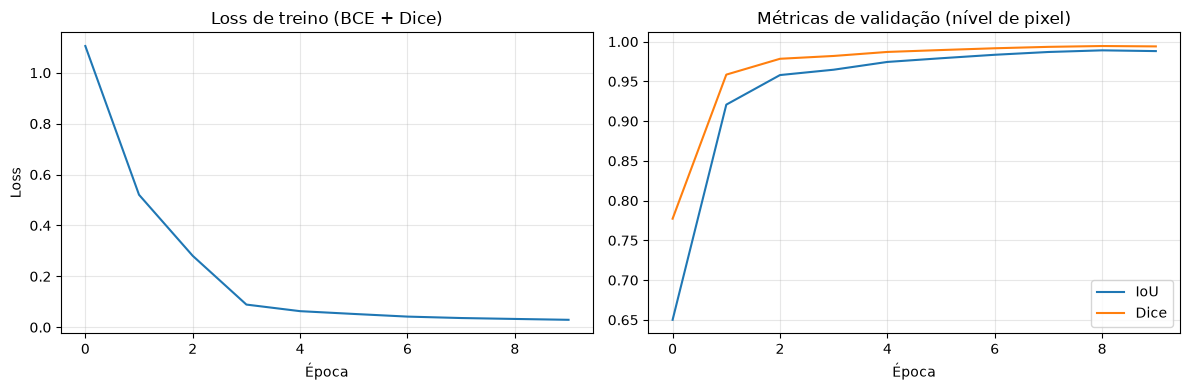

IoU : mAP | Média do mAP por imagem
0.50 : 0.0797 | 0.0533
0.55 : 0.0739 | 0.0476
0.60 : 0.0664 | 0.2154
0.65 : 0.0635 | 0.0000
0.70 : 0.0584 | 0.0353
0.75 : 0.0523 | 0.0667
0.80 : 0.0495 | 0.0766
0.85 : 0.0473 | 0.0000
0.90 : 0.0435 | 0.0667
0.95 : 0.0332 | 0.0000
mAP (IoU 0.50:0.95): 0.0568
Média mAP: 0.0770
Média Erro Absoluto: 11.0149


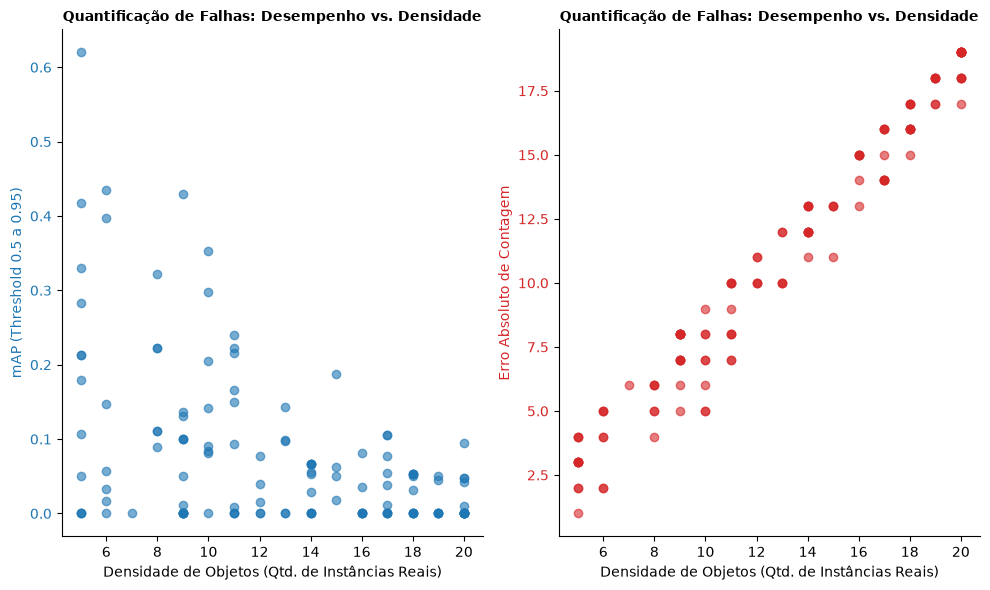

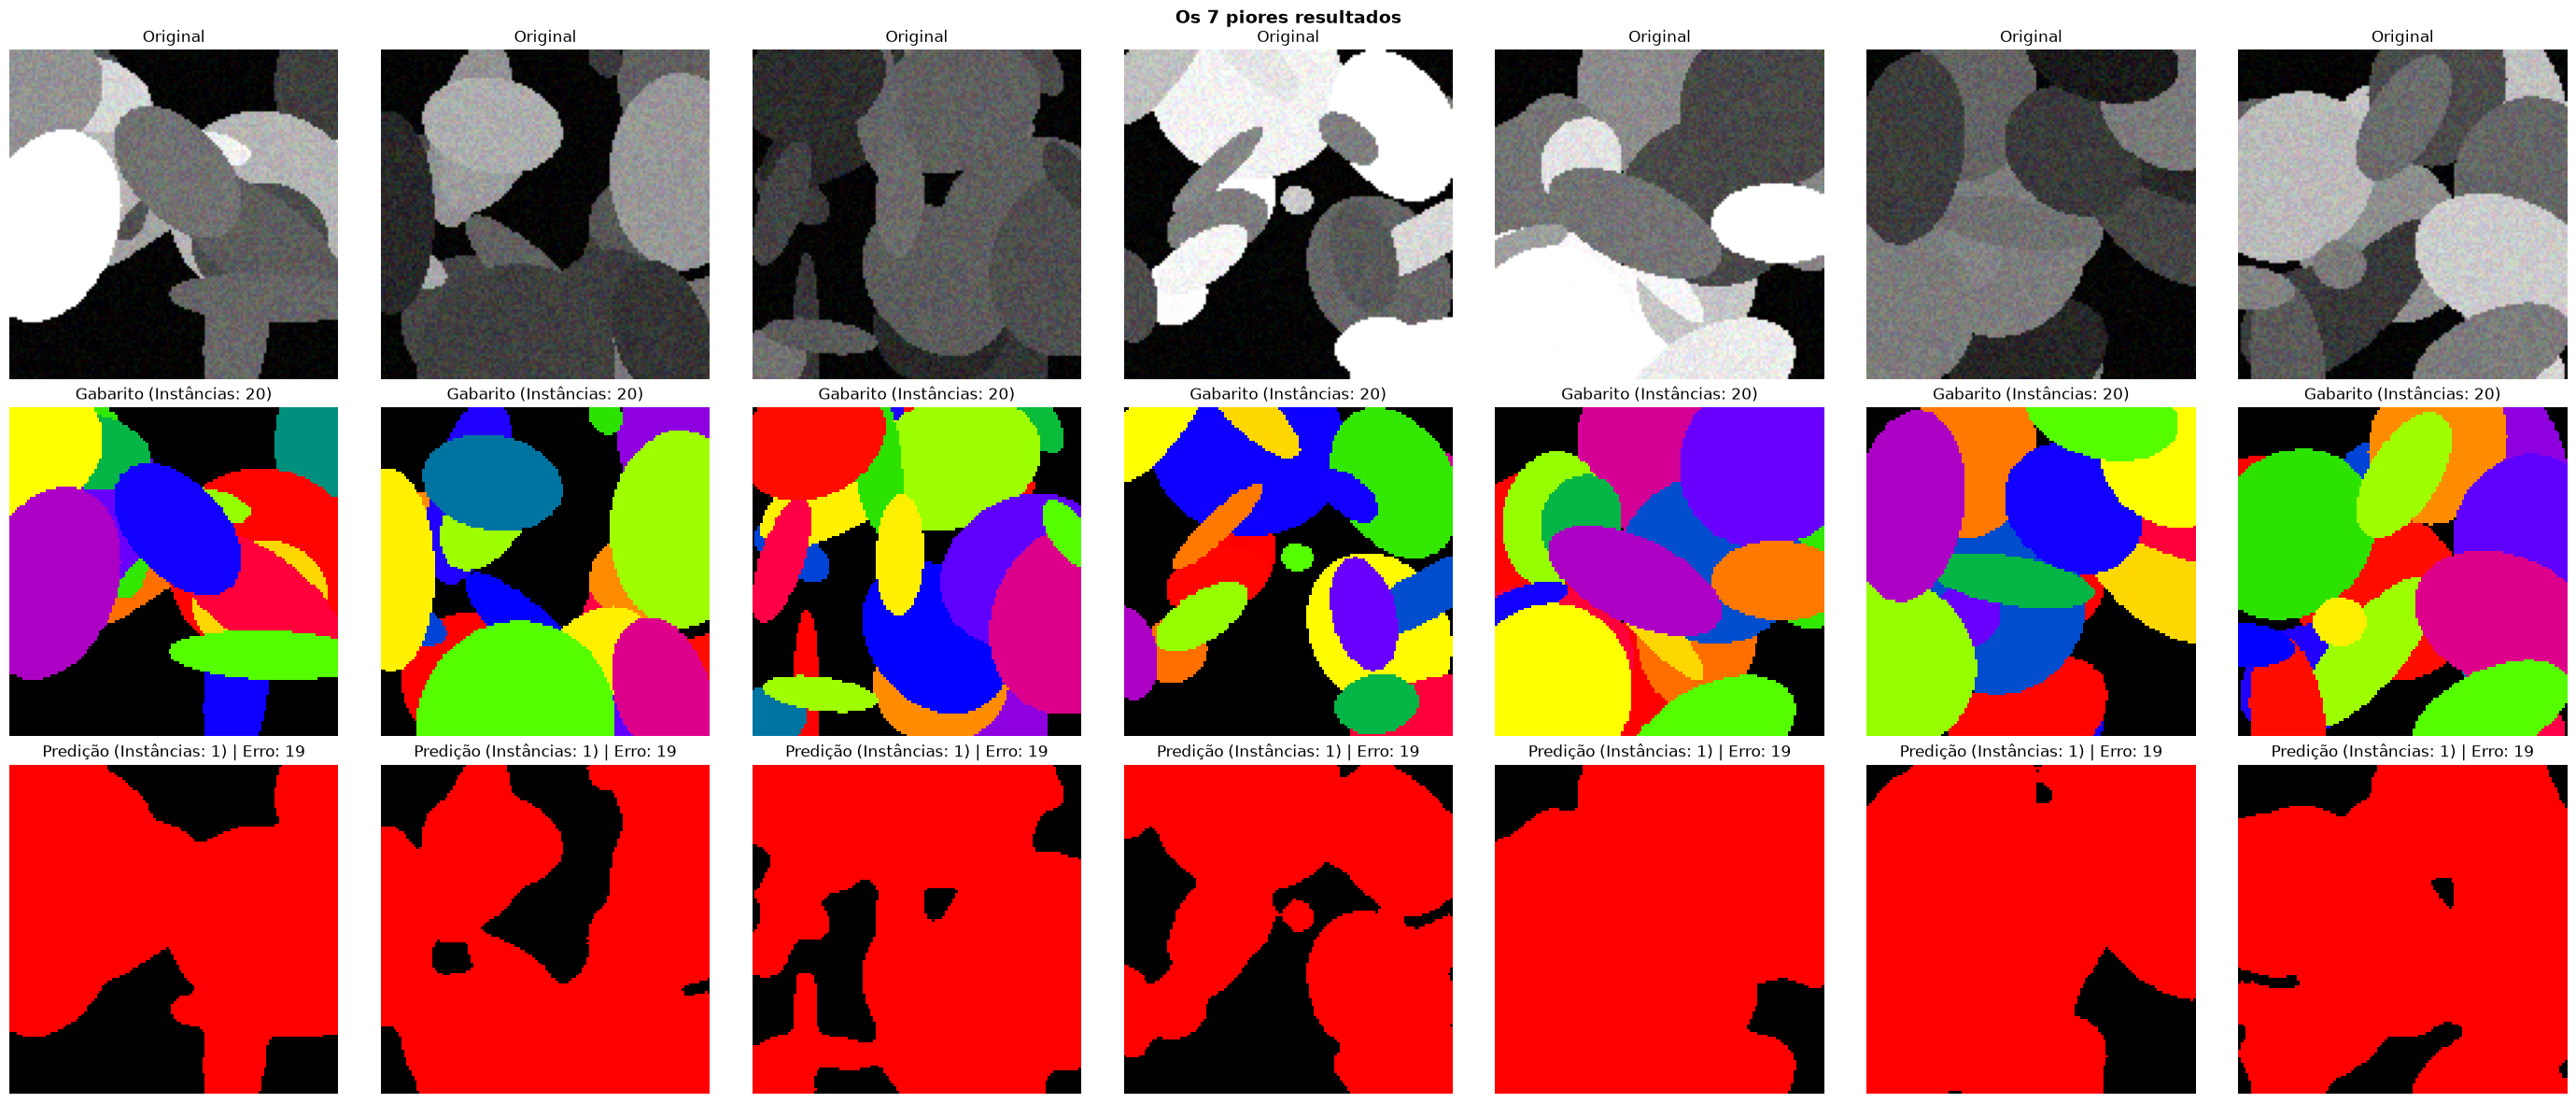

In [3]:
# Inicialização
model_s1 = UNetBinary().to(DEVICE)
full_ds_s1 = SyntheticBinaryDataset(num_samples=670)
train_ds_s1, val_ds_s2 = random_split(full_ds_s1, split(len(full_ds_s1)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s1)} amostras | Val: {len(val_ds_s2)} amostras')

train_loader_s1 = DataLoader(train_ds_s1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_s1 = DataLoader(val_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)


# Treinamento
start_s1 = time.time()
history_s1 = train_model_binary(model_s1, train_loader_s1, val_loader_s1, "s1")
print(f"Tempo de treinamento: {(time.time() - start_s1)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_s1['val_iou']):.4f}")
print(f"Dice corresp.: {history_s1['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_s1)

# Avaliação
model_s1.load_state_dict(torch.load('../models/best_model_s1.pt', map_location=DEVICE, weights_only=True))

aps_s1, count_errors_s1, densities_s1, per_image_aps_s1, samples_s1 = evaluate_instances_binary(model_s1, val_loader_s1)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s1[i]:.4f} | {per_image_aps_s1[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s1):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s1):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s1):.4f}")

plot_metrics(per_image_aps_s1, count_errors_s1, densities_s1)
plot_samples_binary(samples_s1)

Agora vamos para os dados reais:

In [4]:
# Inicialização
model_binary = UNetBinary().to(DEVICE)
full_ds_binary = DSB2018BinaryDataset(PATH_TRAIN)
train_ds_binary, val_ds_binarytrain_ds_binary = random_split(full_ds_binary, split(len(full_ds_binary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_binary)} amostras | Val: {len(val_ds_binarytrain_ds_binary)} amostras')

train_loader_binary = DataLoader(train_ds_binary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_binary = DataLoader(val_ds_binarytrain_ds_binary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


Epoch 1/10 | Loss: 1.4663 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 1.0905 | IoU: 0.0001 | Dice: 0.0003
Epoch 3/10 | Loss: 0.8120 | IoU: 0.5072 | Dice: 0.6593
Epoch 4/10 | Loss: 0.5419 | IoU: 0.6133 | Dice: 0.7464
Epoch 5/10 | Loss: 0.4146 | IoU: 0.6575 | Dice: 0.7808
Epoch 6/10 | Loss: 0.3623 | IoU: 0.6891 | Dice: 0.8045
Epoch 7/10 | Loss: 0.3377 | IoU: 0.6947 | Dice: 0.8078
Epoch 8/10 | Loss: 0.3254 | IoU: 0.7276 | Dice: 0.8338
Epoch 9/10 | Loss: 0.3168 | IoU: 0.7335 | Dice: 0.8363
Epoch 10/10 | Loss: 0.2957 | IoU: 0.7313 | Dice: 0.8367
Tempo de treinamento: 1.15 minutos
Melhor IoU (val): 0.7335
Dice corresp.: 0.8367


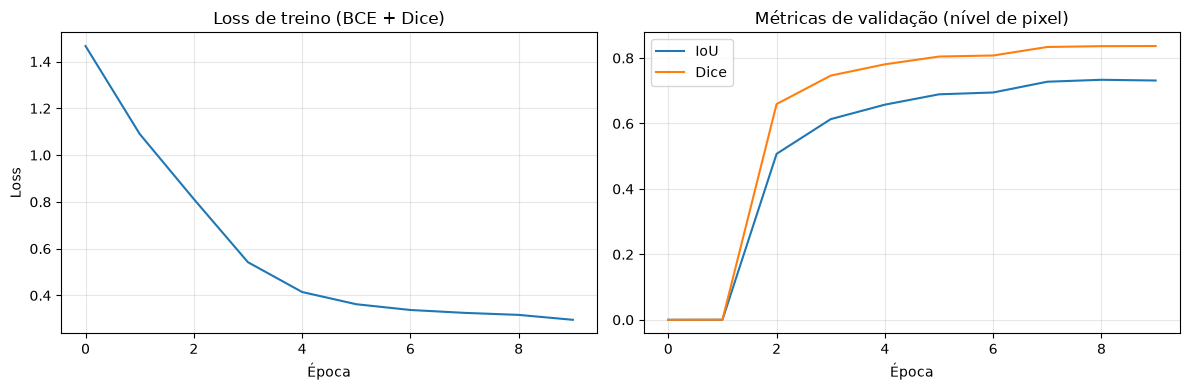

In [5]:
# Treinamento
start_binary = time.time()
history_binary = train_model_binary(model_binary, train_loader_binary, val_loader_binary, "binary")
print(f"Tempo de treinamento: {(time.time() - start_binary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_binary['val_iou']):.4f}")
print(f"Dice corresp.: {history_binary['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_binary)

IoU : mAP | Média do mAP por imagem
0.50 : 0.3051 | 0.1531
0.55 : 0.2794 | 0.1907
0.60 : 0.2560 | 0.2586
0.65 : 0.2311 | 0.1652
0.70 : 0.1953 | 0.7416
0.75 : 0.1492 | 0.0068
0.80 : 0.1082 | 0.5451
0.85 : 0.0679 | 0.5905
0.90 : 0.0316 | 0.0563
0.95 : 0.0048 | 0.0507
mAP (IoU 0.50:0.95): 0.1629
Média mAP: 0.2877
Média Erro Absoluto: 24.7910


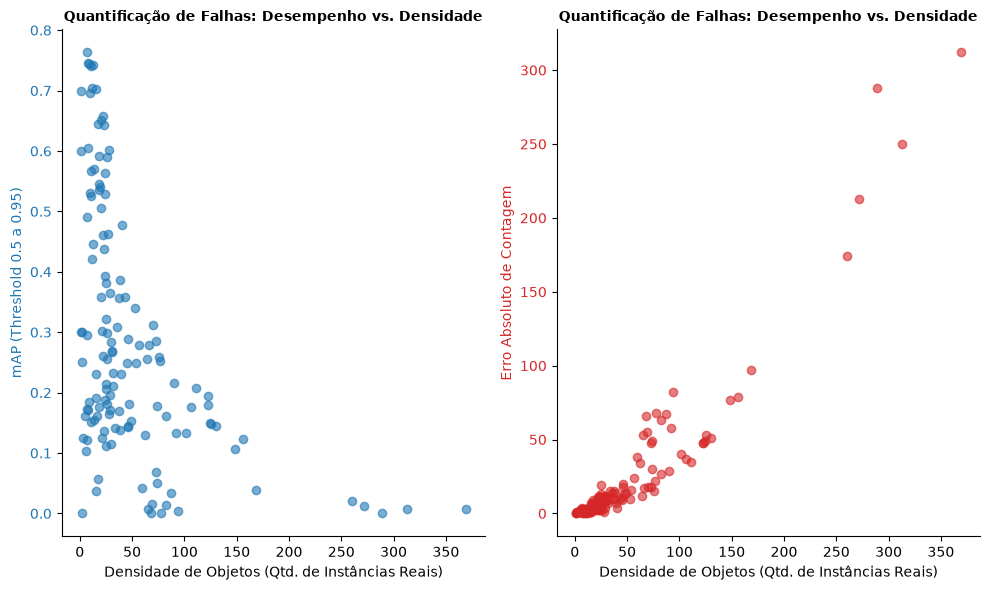

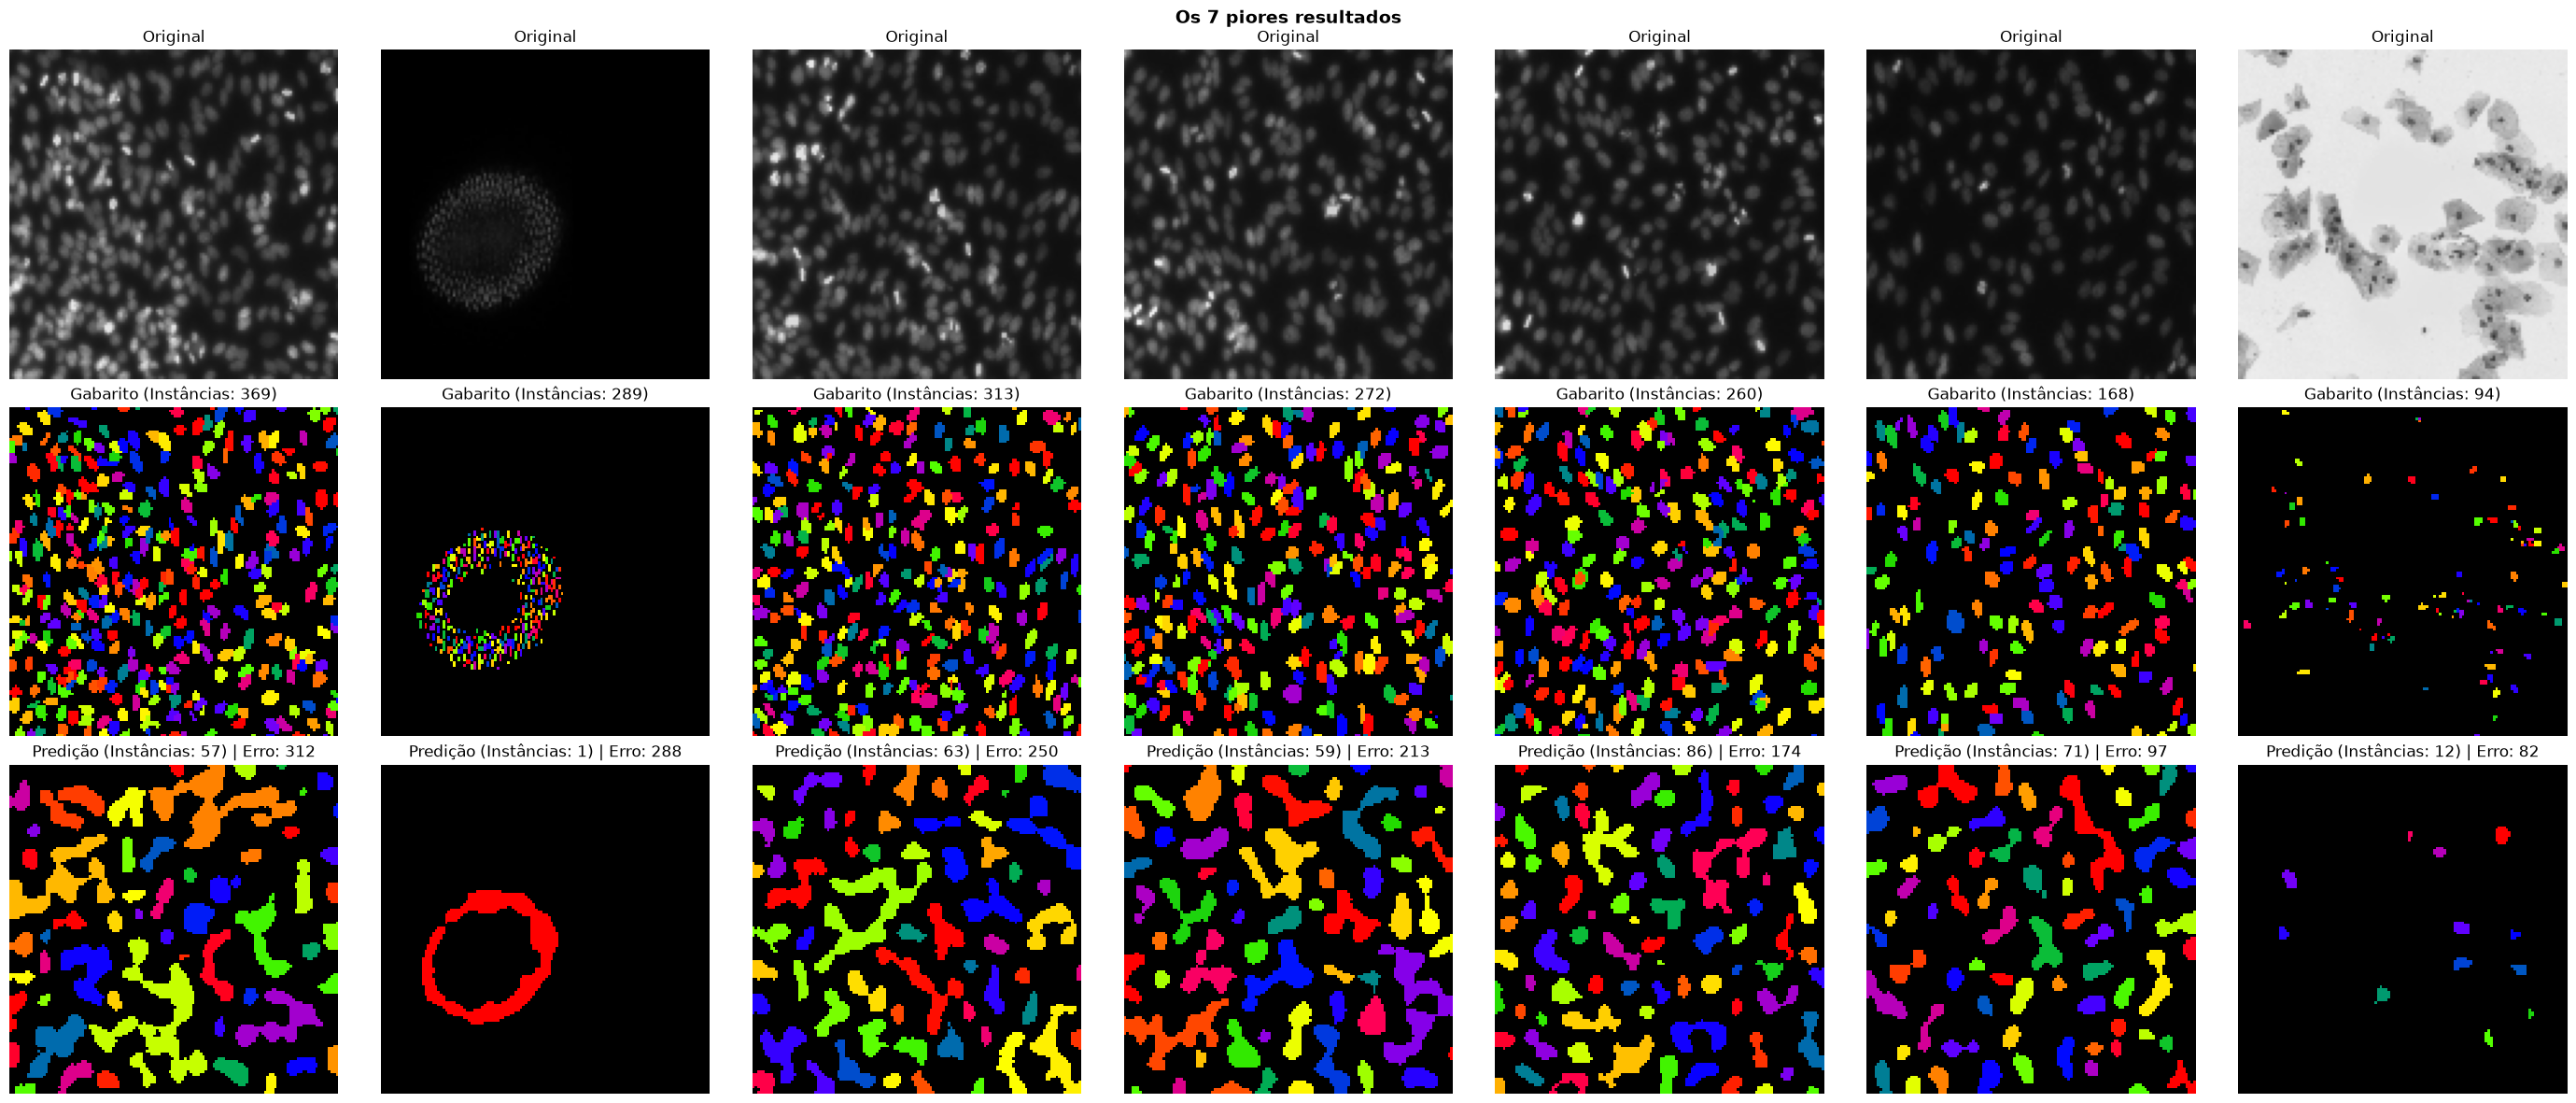

In [6]:
# Avaliação
model_binary.load_state_dict(torch.load('../models/best_model_binary.pt', map_location=DEVICE, weights_only=True))

aps_binary, count_errors_binary, densities_binary, per_image_aps_binary, samples_binary = evaluate_instances_binary(model_binary, val_loader_binary)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_binary[i]:.4f} | {per_image_aps_binary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_binary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_binary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_binary):.4f}")

plot_metrics(per_image_aps_binary, count_errors_binary, densities_binary)
plot_samples_binary(samples_binary)

### Parte 2

Primeiramente vamos usar os dados sintéticos:

Train: 536 amostras | Val: 134 amostras
Epoch 01/10 | Train Loss: 0.8629 | Val Loss: 0.2725 (Cls: 0.1577, Dist: 0.1148)
Epoch 02/10 | Train Loss: 0.5352 | Val Loss: 0.2793 (Cls: 0.1692, Dist: 0.1100)
Epoch 03/10 | Train Loss: 0.4806 | Val Loss: 0.2489 (Cls: 0.1431, Dist: 0.1058)
Epoch 04/10 | Train Loss: 0.4284 | Val Loss: 0.2398 (Cls: 0.1585, Dist: 0.0813)
Epoch 05/10 | Train Loss: 0.4035 | Val Loss: 0.2106 (Cls: 0.1380, Dist: 0.0727)
Epoch 06/10 | Train Loss: 0.4000 | Val Loss: 0.1994 (Cls: 0.1289, Dist: 0.0705)
Epoch 07/10 | Train Loss: 0.3705 | Val Loss: 0.1859 (Cls: 0.1260, Dist: 0.0598)
Epoch 08/10 | Train Loss: 0.3683 | Val Loss: 0.1877 (Cls: 0.1258, Dist: 0.0619)
Epoch 09/10 | Train Loss: 0.3723 | Val Loss: 0.1975 (Cls: 0.1397, Dist: 0.0578)
Epoch 10/10 | Train Loss: 0.3712 | Val Loss: 0.2167 (Cls: 0.1547, Dist: 0.0620)
Tempo de treinamento: 3.00 minutos


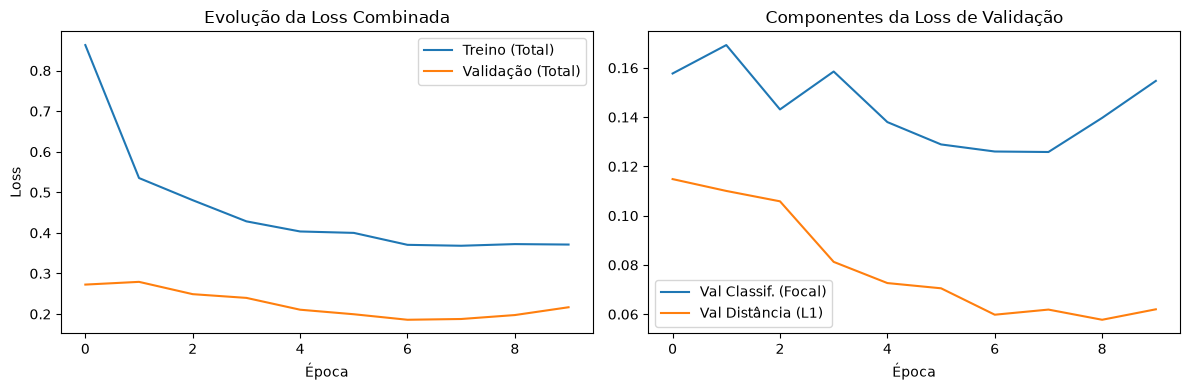

IoU : mAP | Média do mAP por imagem
0.50 : 0.1778 | 0.0143
0.55 : 0.1682 | 0.0862
0.60 : 0.1587 | 0.2225
0.65 : 0.1501 | 0.7548
0.70 : 0.1421 | 0.0500
0.75 : 0.1325 | 0.2516
0.80 : 0.1212 | 0.0063
0.85 : 0.1073 | 0.5984
0.90 : 0.0949 | 0.5925
0.95 : 0.0789 | 0.0859
mAP (IoU 0.50:0.95): 0.1332
Média mAP: 0.1837
Média Erro Absoluto: 9.0149


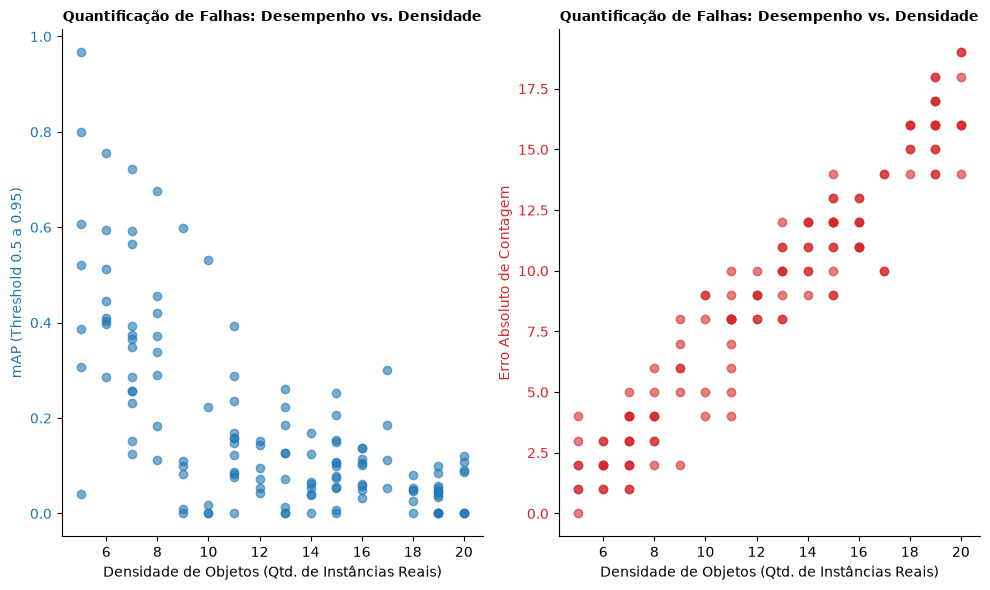

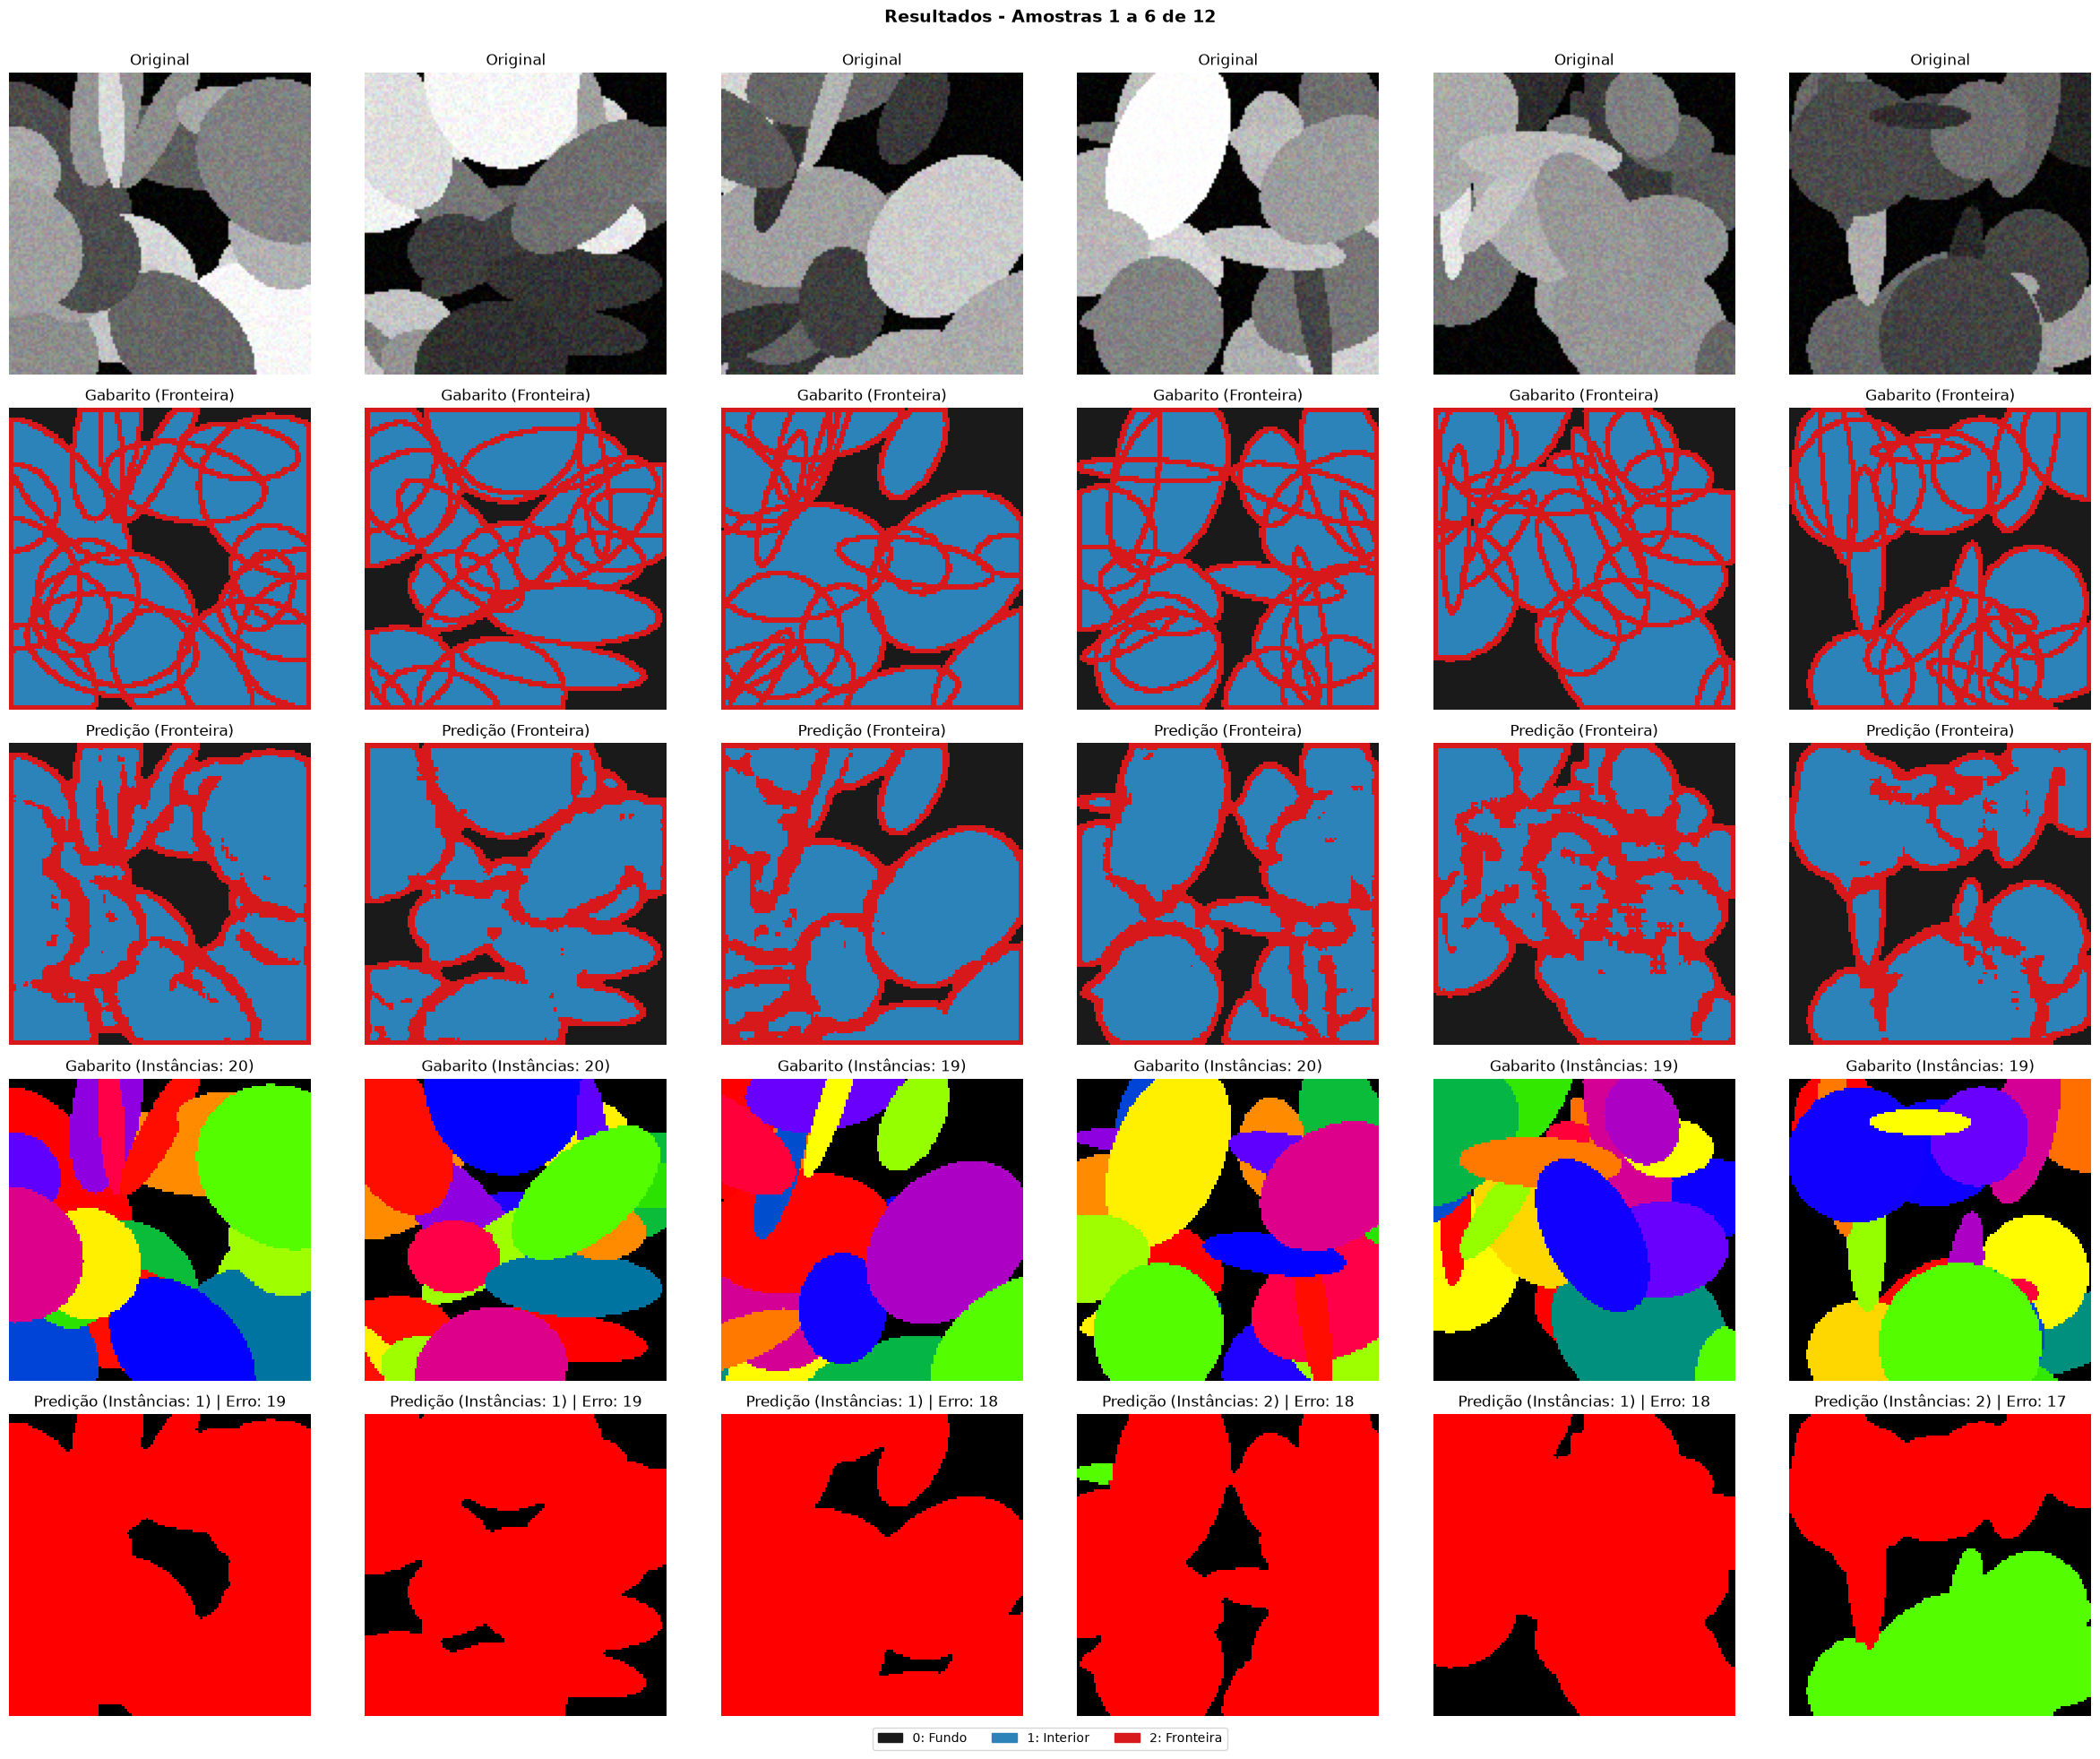

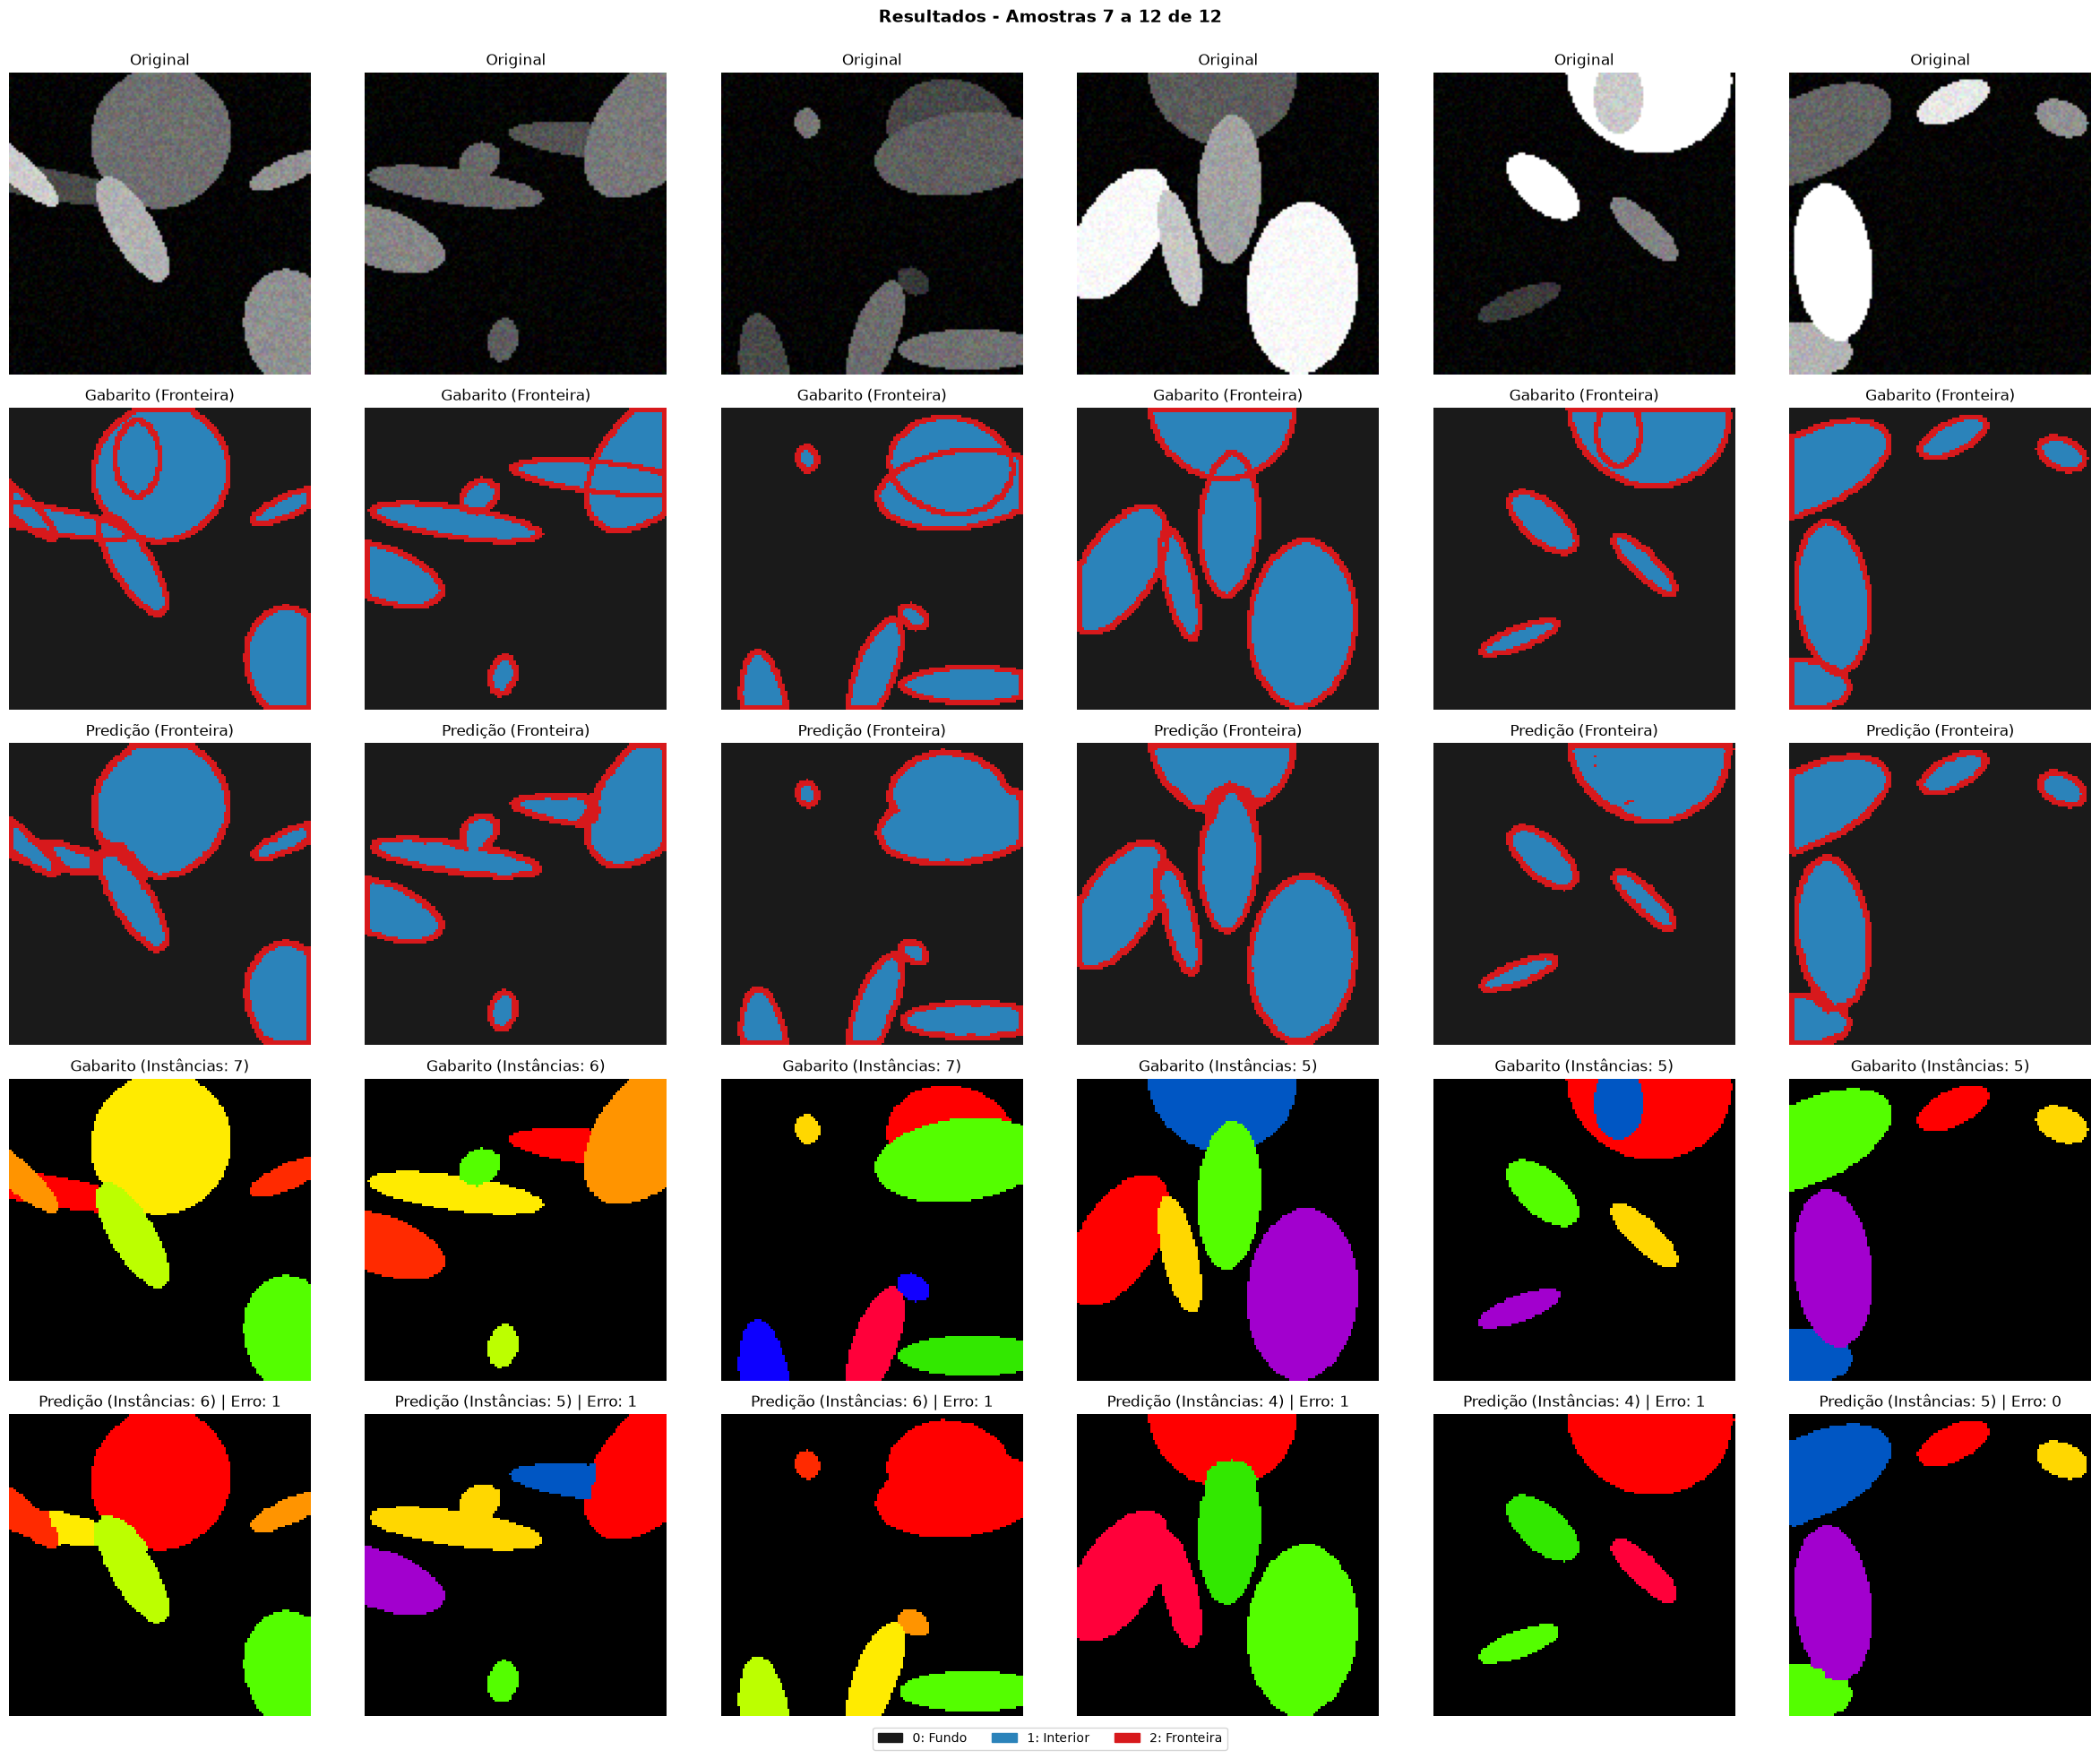

In [7]:
# Inicialização
model_s2 = UNetTernary().to(DEVICE)
full_ds_s2 = SyntheticTernaryDataset(num_samples=670)
train_ds_s2, val_ds_s2train_ds_s2 = random_split(full_ds_s2, split(len(full_ds_s2)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s2)} amostras | Val: {len(val_ds_s2train_ds_s2)} amostras')

train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_s2 = DataLoader(val_ds_s2train_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

# Treinamento
start_s2 = time.time()
history_s2 = train_model_ternary(model_s2, train_loader_s2, val_loader_s2, "s2")
print(f"Tempo de treinamento: {(time.time() - start_s2)/60:.2f} minutos")
plot_training_curves_ternary(history_s2)

# Avaliação
model_s2.load_state_dict(torch.load('../models/best_model_s2.pt', map_location=DEVICE, weights_only=True))
aps_s2, count_errors_s2, densities_s2, per_image_aps_s2, samples_s2 = evaluate_instances_ternary(model_s2, val_loader_s2)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s2[i]:.4f} | {per_image_aps_s2[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s2):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s2):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s2):.4f}")

plot_metrics(per_image_aps_s2, count_errors_s2, densities_s2)
plot_samples_ternary(samples_s2)

Agora vamos para os dados reais:

In [8]:
# Inicialização
model_ternary = UNetTernary().to(DEVICE)
full_ds_ternary = DSB2018TernaryDataset(PATH_TRAIN, img_size=256)
train_ds_ternary, val_ds_ternary = random_split(full_ds_ternary, split(len(full_ds_ternary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ternary)} amostras | Val: {len(val_ds_ternary)} amostras')

train_loader_ternary = DataLoader(train_ds_ternary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_ternary = DataLoader(val_ds_ternary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


Epoch 01/10 | Train Loss: 0.6500 | Val Loss: 0.2465 (Cls: 0.1958, Dist: 0.0506)
Epoch 02/10 | Train Loss: 0.3476 | Val Loss: 0.1711 (Cls: 0.1346, Dist: 0.0365)
Epoch 03/10 | Train Loss: 0.2530 | Val Loss: 0.1448 (Cls: 0.1082, Dist: 0.0365)
Epoch 04/10 | Train Loss: 0.2255 | Val Loss: 0.1211 (Cls: 0.0900, Dist: 0.0311)
Epoch 05/10 | Train Loss: 0.2034 | Val Loss: 0.1329 (Cls: 0.1018, Dist: 0.0311)
Epoch 06/10 | Train Loss: 0.2050 | Val Loss: 0.1108 (Cls: 0.0808, Dist: 0.0300)
Epoch 07/10 | Train Loss: 0.1857 | Val Loss: 0.1033 (Cls: 0.0737, Dist: 0.0295)
Epoch 08/10 | Train Loss: 0.1770 | Val Loss: 0.0999 (Cls: 0.0717, Dist: 0.0283)
Epoch 09/10 | Train Loss: 0.1722 | Val Loss: 0.1041 (Cls: 0.0761, Dist: 0.0279)
Epoch 10/10 | Train Loss: 0.1732 | Val Loss: 0.1028 (Cls: 0.0734, Dist: 0.0294)
Tempo de treinamento: 6.11 minutos


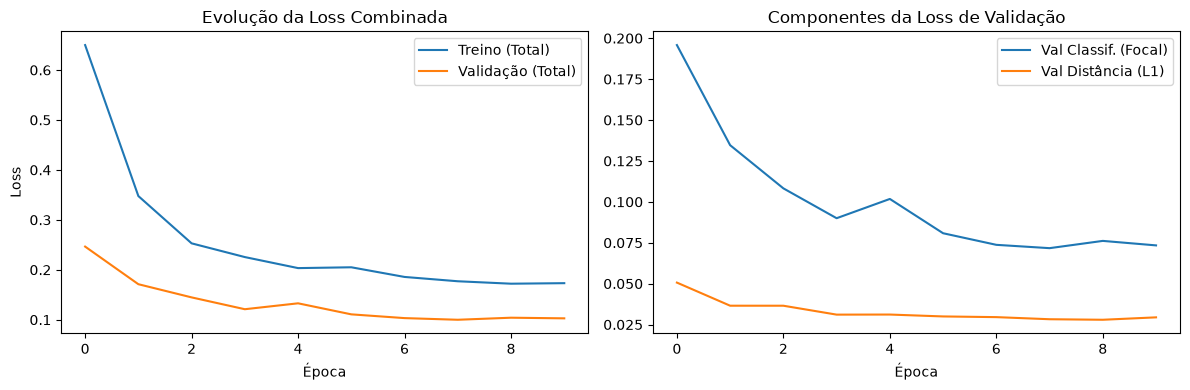

In [9]:
# Treinamento
start_ternary = time.time()
history_ternary = train_model_ternary(model_ternary, train_loader_ternary, val_loader_ternary, "ternary")
print(f"Tempo de treinamento: {(time.time() - start_ternary)/60:.2f} minutos")
plot_training_curves_ternary(history_ternary)


IoU : mAP | Média do mAP por imagem
0.50 : 0.5802 | 0.3132
0.55 : 0.5563 | 0.3646
0.60 : 0.5314 | 0.6141
0.65 : 0.5040 | 0.5285
0.70 : 0.4599 | 0.8522
0.75 : 0.3958 | 0.1466
0.80 : 0.3146 | 0.5561
0.85 : 0.2119 | 0.7511
0.90 : 0.1022 | 0.1177
0.95 : 0.0163 | 0.2831
mAP (IoU 0.50:0.95): 0.3673
Média mAP: 0.4781
Média Erro Absoluto: 13.8060


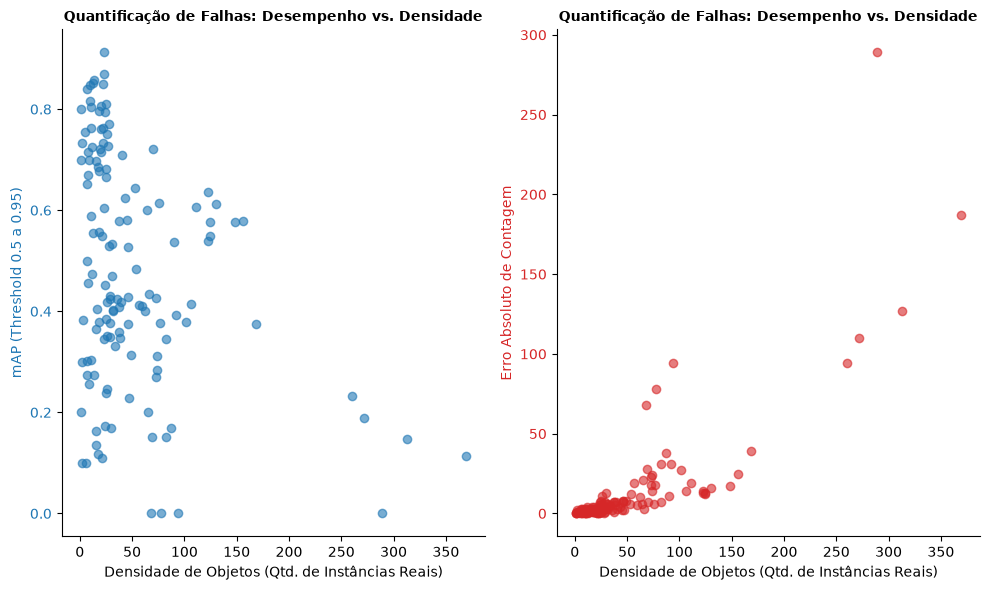

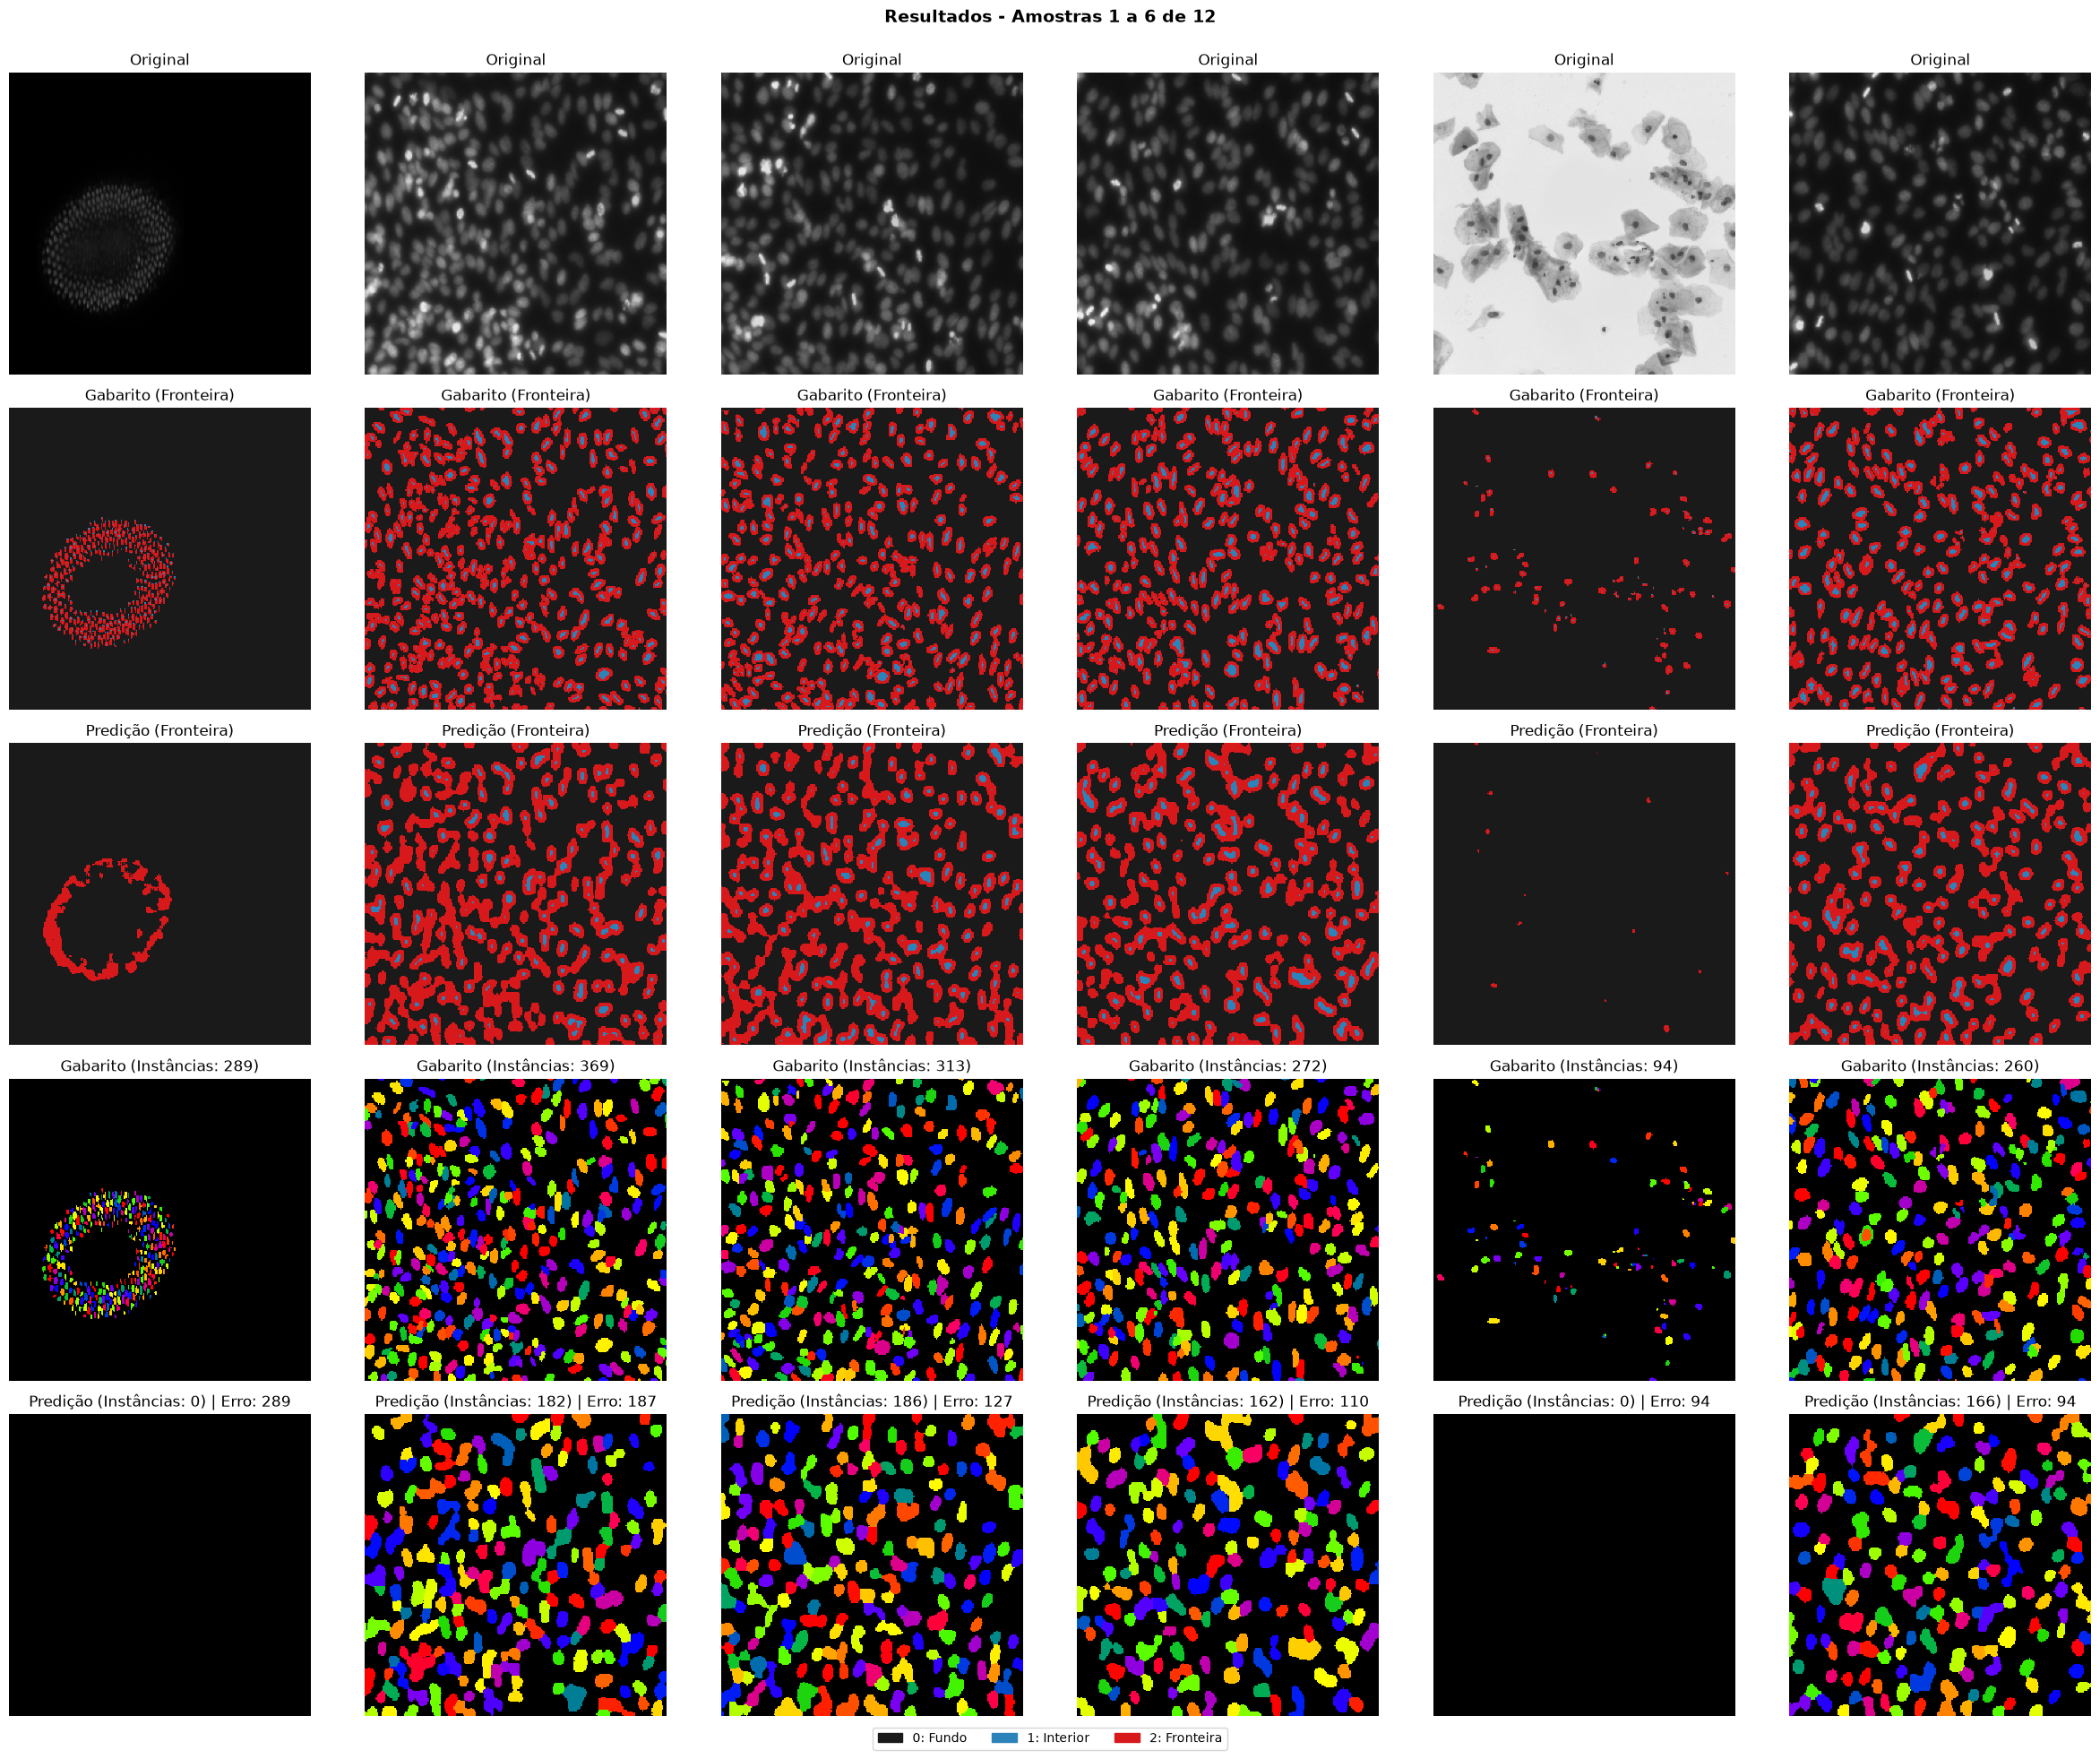

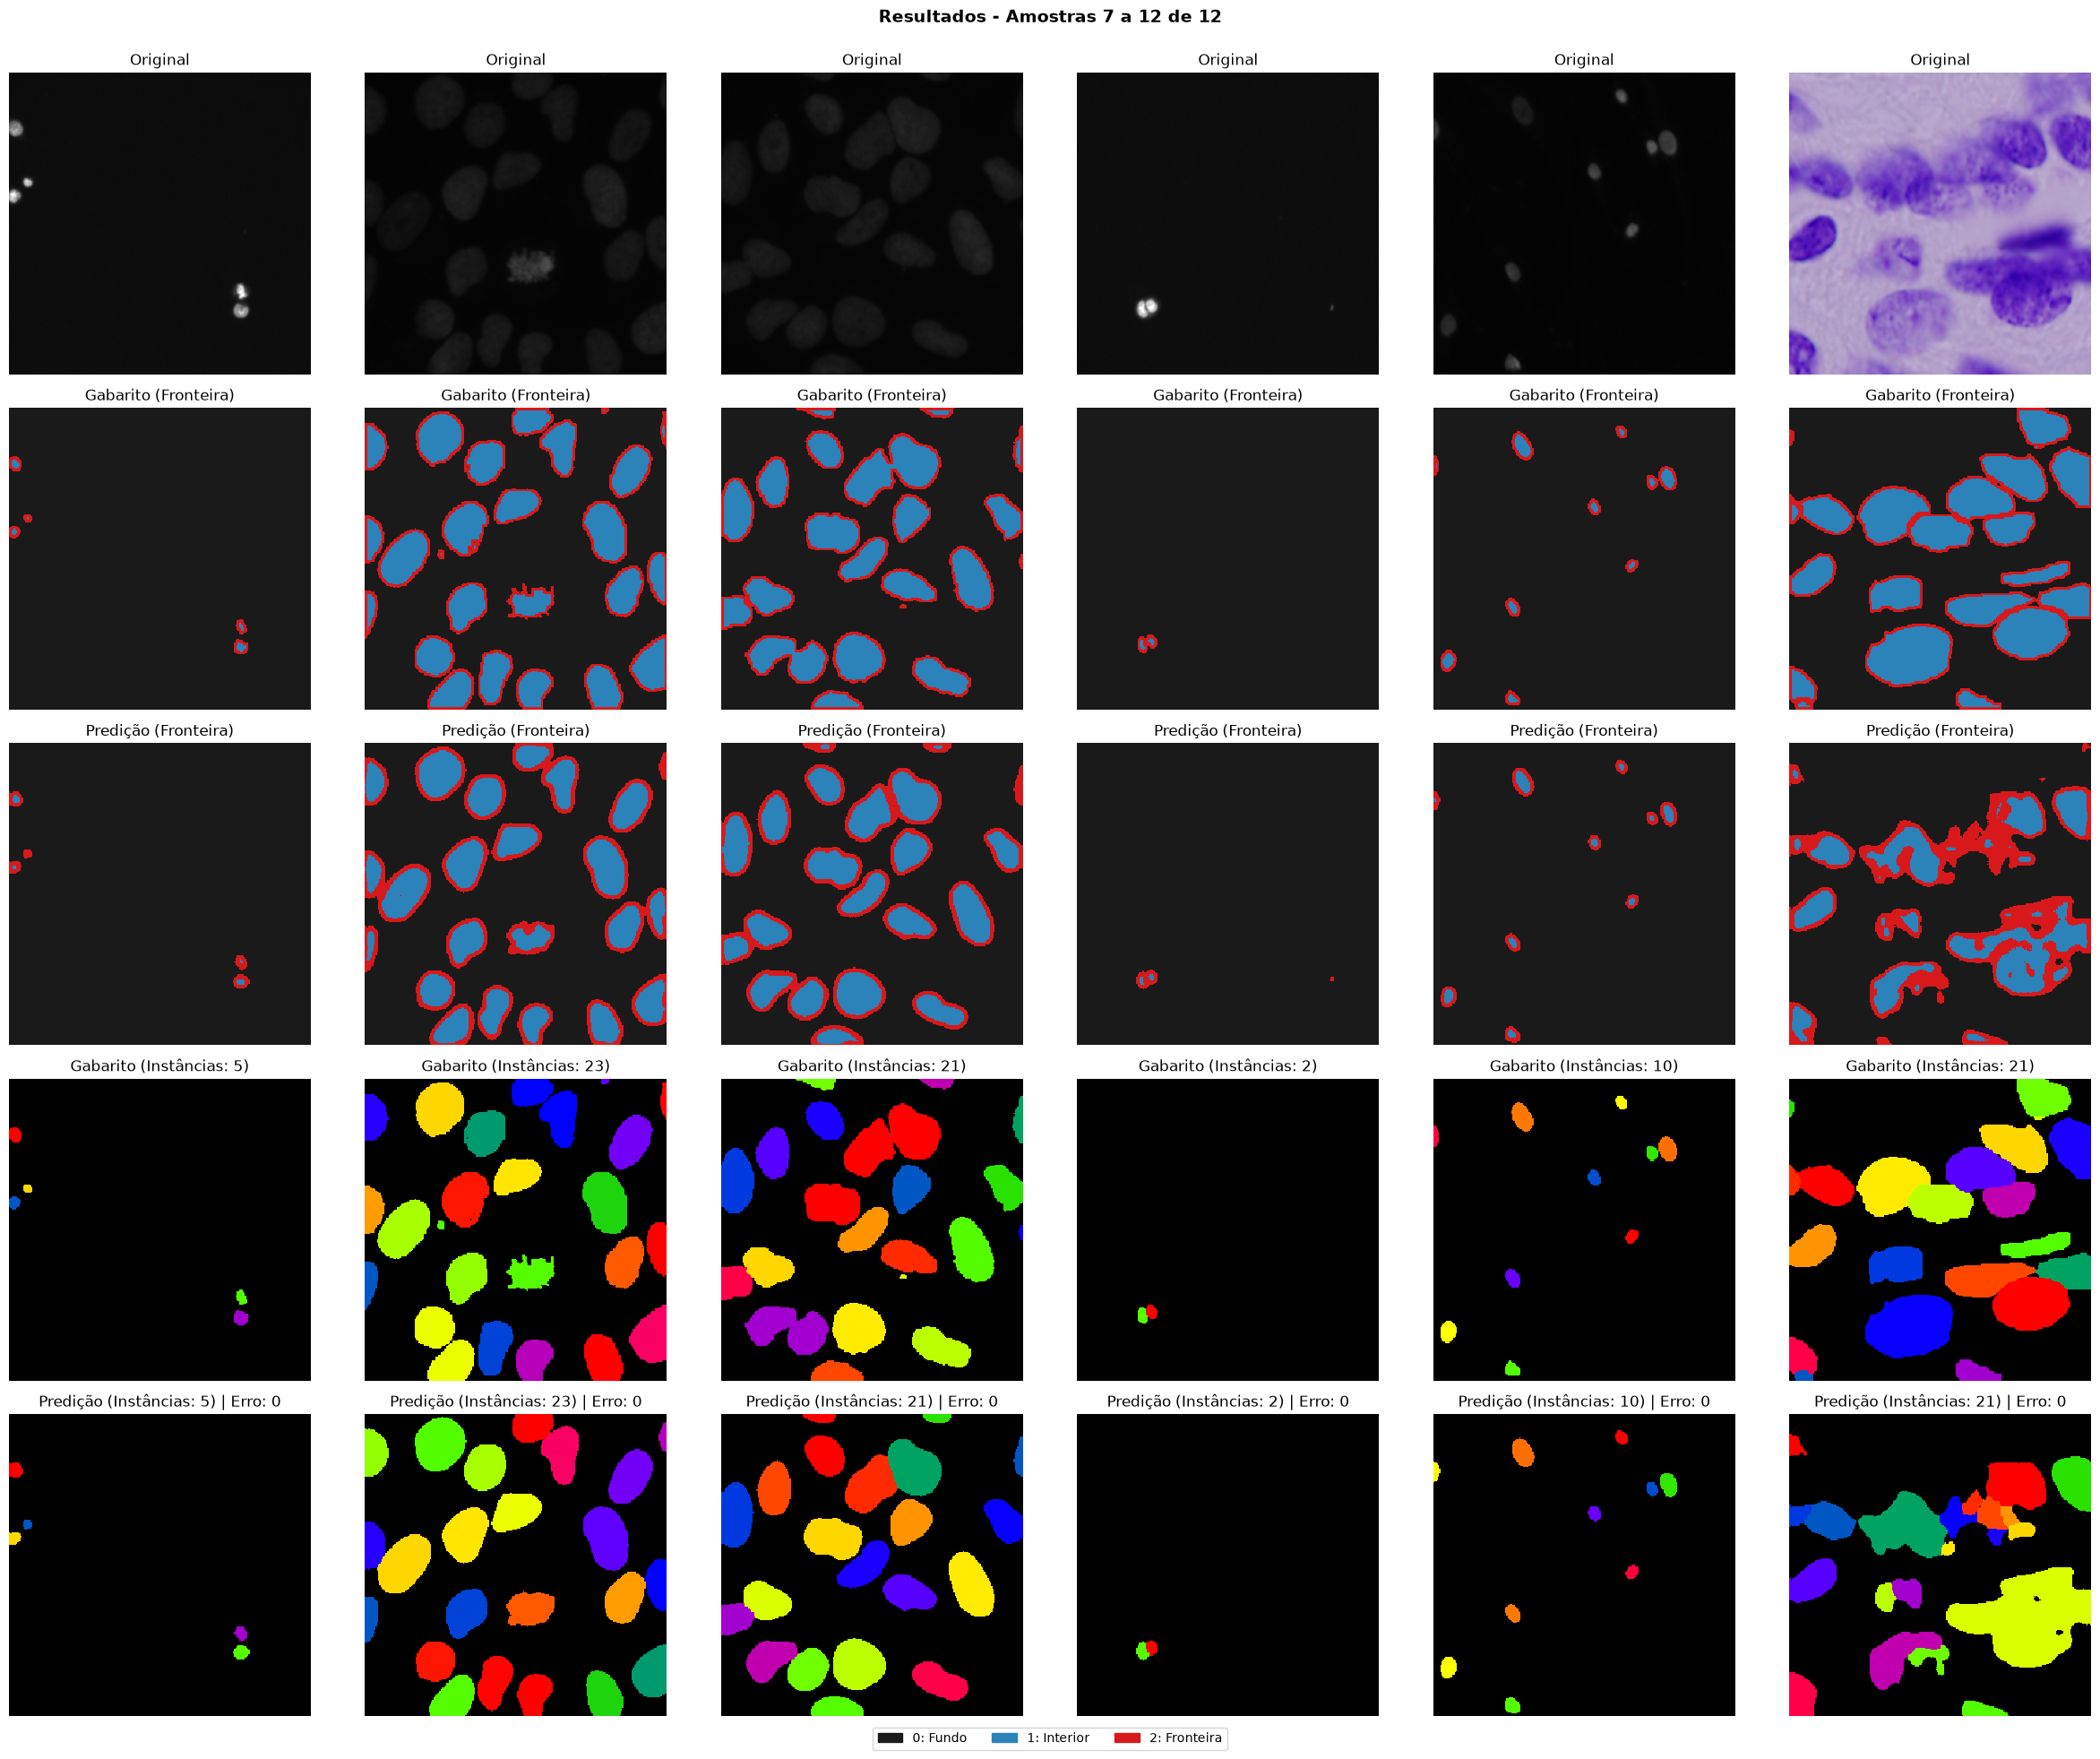

In [ ]:
# Avaliação
model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

aps_ternary, count_errors_ternary, densities_ternary, per_image_aps_ternary, samples_ternary = evaluate_instances_ternary(model_ternary, val_loader_ternary, csv_path="../models/metrics_per_image.csv")

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_ternary[i]:.4f} | {per_image_aps_ternary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_ternary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_ternary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_ternary):.4f}")


plot_metrics(per_image_aps_ternary, count_errors_ternary, densities_ternary)
plot_samples_ternary(samples_ternary)


Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

### Parte 3

In [17]:
full_ds_ablation = DSB2018TernaryDataset(PATH_TRAIN, img_size=256)
train_ds_ablation, val_ds_ablation = random_split(full_ds_ablation, split(len(full_ds_ablation)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ablation)} amostras | Val: {len(val_ds_ablation)} amostras')

df_summary, df_runs = ablation(train_ds_ablation, val_ds_ablation)

# Exibe a tabela formatada (média ± desvio)
print("\n" + "="*80)
print("TABELA DE ABLAÇÕES TERNÁRIAS (MÉDIA ± DESVIO PADRÃO)")
print("="*80)
print(df_summary.to_markdown())

Train: 536 amostras | Val: 134 amostras

[Ablation Ternária] Configuração: Eixo1_SkipConnections (UNet)

--> Iniciando Seed: 42
Epoch 01/10 | Train Loss: 1.5169 | Val Loss: 0.6404 (Cls: 0.3160, Dist: 0.3244)
Epoch 02/10 | Train Loss: 0.6548 | Val Loss: 0.3212 (Cls: 0.2360, Dist: 0.0852)
Epoch 03/10 | Train Loss: 0.4297 | Val Loss: 0.2324 (Cls: 0.1785, Dist: 0.0539)
Epoch 04/10 | Train Loss: 0.3525 | Val Loss: 0.1846 (Cls: 0.1453, Dist: 0.0393)
Epoch 05/10 | Train Loss: 0.3001 | Val Loss: 0.1468 (Cls: 0.1105, Dist: 0.0362)
Epoch 06/10 | Train Loss: 0.2553 | Val Loss: 0.1229 (Cls: 0.0896, Dist: 0.0333)
Epoch 07/10 | Train Loss: 0.2257 | Val Loss: 0.1275 (Cls: 0.0958, Dist: 0.0317)
Epoch 08/10 | Train Loss: 0.2098 | Val Loss: 0.1172 (Cls: 0.0866, Dist: 0.0307)
Epoch 09/10 | Train Loss: 0.1971 | Val Loss: 0.1188 (Cls: 0.0883, Dist: 0.0306)
Epoch 10/10 | Train Loss: 0.1901 | Val Loss: 0.1128 (Cls: 0.0830, Dist: 0.0298)
Resultado Seed 42 | Val Loss: 0.1128 | mAP: 0.2465 | AP@50: 0.4108 | Err

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

In [33]:
print(df_summary.to_markdown())

| Configuração                         | Val Loss      | mAP [0.5:0.95]   | AP@50           | AP@75           | Erro Contagem   |
|:-------------------------------------|:--------------|:-----------------|:----------------|:----------------|:----------------|
| Eixo1_ASPP (DeepLab)                 | 0.242 ± 0.002 | 0.0002 ± 0.0004  | 0.0011 ± 0.0015 | 0.0001 ± 0.0001 | 49.388 ± 0.190  |
| Eixo1_PoolIndices (SegNet)           | 0.389 ± 0.122 | 0.1273 ± 0.0243  | 0.3178 ± 0.1127 | 0.0805 ± 0.0209 | 16.981 ± 0.227  |
| Eixo1_SkipConnections (UNet)         | 0.114 ± 0.002 | 0.2473 ± 0.0011  | 0.4080 ± 0.0040 | 0.2617 ± 0.0023 | 22.642 ± 0.296  |
| Eixo3_Baseline (Sem Contexto Global) | 0.113 ± 0.000 | 0.2464 ± 0.0018  | 0.4073 ± 0.0053 | 0.2603 ± 0.0045 | 22.638 ± 0.533  |
| Eixo3_ImagePooling (ParseNet)        | 0.117 ± 0.001 | 0.2279 ± 0.0332  | 0.3917 ± 0.0212 | 0.2319 ± 0.0570 | 22.291 ± 0.127  |
| Eixo3_PyramidPooling (PSPNet)        | 0.116 ± 0.001 | 0.2269 ± 0.0401  | 0.3967 ± 0.025

### Parte 4

In [10]:
mosaic_img, mosaic_inst = create_mosaic_real(val_ds_ternary, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")


📦 Formato da imagem do mosaico: (3, 512, 512)
🏷️ Formato da máscara de instâncias do mosaico: (512, 512)
🔢 Total de instâncias únicas no mosaico: 168


In [11]:
tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

🧩 Número total de tiles gerados: 25
📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: (0, 128, 0, 128)
📦 Formato de cada tile: (3, 128, 128)


Número de instâncias: 266


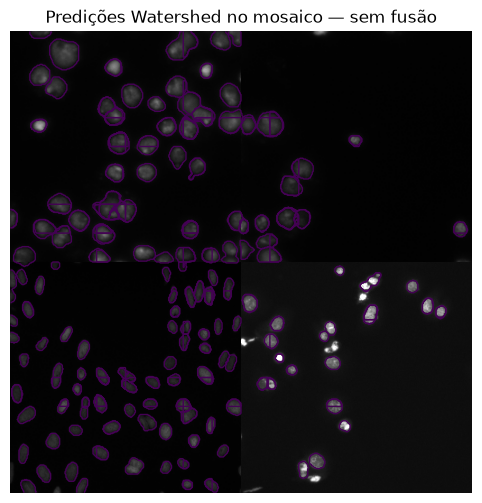

In [12]:
model_mosaic = UNetTernary().to(DEVICE)
model_mosaic.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

pred_naive = mosaic_inference_naive_watershed(
    model=model_mosaic,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5
)
print("Número de instâncias:", len(pred_naive))

plt.figure(figsize=(12, 6))

plt.imshow(mosaic_img.transpose(1, 2, 0))

for mask in pred_naive:
    plt.contour(mask, levels=[0.5], linewidths=1)

plt.axis("off")
plt.title("Predições Watershed no mosaico — sem fusão")
plt.show()

In [13]:
pred_fusion_labels = mosaic_inference_watershed_with_fusion(
    model=model_mosaic,
    large_image=mosaic_img,
    tile_size=128,
    overlap=32,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5,
    fusion_iou_thresh=0.3,
)

pred_fusion = label_mask_to_instances(
    pred_fusion_labels
)

In [14]:
print("Número de instâncias após fusão:",
      len(np.unique(pred_fusion_labels)) - 1)

Número de instâncias após fusão: 147


In [15]:
for thresh in [0.2, 0.3, 0.5, 0.7]:
    
    pred = mosaic_inference_watershed_with_fusion(
        model=model_mosaic,
        large_image=mosaic_img,
        tile_size=128,
        overlap=32,
        device=DEVICE,
        interior_thresh=0.4,
        fg_thresh=0.5,
        min_marker_size=5,
        fusion_iou_thresh=thresh,
    )

    n_instances = len(np.unique(pred)) - 1

    print(
        f"IoU = {thresh:.1f} → "
        f"{n_instances} instâncias"
    )

IoU = 0.2 → 146 instâncias
IoU = 0.3 → 147 instâncias
IoU = 0.5 → 149 instâncias
IoU = 0.7 → 151 instâncias


In [16]:
gt_masks = label_mask_to_instances(mosaic_inst)

print("Número de instâncias GT:", len(gt_masks))
print("Shape de cada máscara:", gt_masks[0].shape)

Número de instâncias GT: 168
Shape de cada máscara: (512, 512)


In [17]:
aps_naive, map_naive, count_naive = evaluate_mosaic_instances(
    pred_naive,
    gt_masks
)

aps_fusion, map_fusion, count_fusion = evaluate_mosaic_instances(
    pred_fusion,
    gt_masks
)

In [18]:
print("======================================")
print("NAIVE")
print("======================================")
print(f"Instâncias previstas: {len(pred_naive)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_naive}")
print(f"mAP:                  {map_naive:.4f}")

print()

print("======================================")
print("FUSION")
print("======================================")
print(f"Instâncias previstas: {len(pred_fusion)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_fusion}")
print(f"mAP:                  {map_fusion:.4f}")

NAIVE
Instâncias previstas: 266
Instâncias GT:        168
Erro de contagem:     98
mAP:                  0.2762

FUSION
Instâncias previstas: 147
Instâncias GT:        168
Erro de contagem:     21
mAP:                  0.4221


A inferência naive produziu 246 instâncias para 168 instâncias reais, resultando em erro absoluto de contagem de 78 objetos e mAP de 0,2819. Após a aplicação da fusão baseada em IoU nas regiões de sobreposição dos tiles, o número de instâncias previstas foi reduzido para 139, diminuindo o erro de contagem para 29 e elevando o mAP para 0,4104. Os resultados indicam que uma parcela significativa das detecções adicionais da abordagem naive correspondia a duplicações de instâncias entre tiles. Entretanto, a fusão também pode eliminar ou unir incorretamente algumas instâncias, como indicado pela subcontagem final de 29 objetos.

### Parte 5

In [19]:
path_train = Path('../data/stage1_train')
df = pd.read_csv('../models/metrics_per_image.csv')
df_sorted_error = df.sort_values(by = 'count_error', ascending=False)
df_sorted_map = df.sort_values(by = 'mAP_image')
df_sorted_error.head(5)

,id,n_gt,n_pred,count_error,mAP_image
49,20b20ab049372d184c705acebe7af026d3580f5fd5a72e...,289,0,289,0.000000
90,0ea221716cf13710214dcd331a61cea48308c3940df1d2...,369,182,187,0.113498
5,07fb37aafa6626608af90c1e18f6a743f29b6b233d2e42...,313,186,127,0.146580
98,5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b9375...,272,162,110,0.188850
50,8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc...,94,0,94,0.000000


In [20]:
# Analisar as falhas

top_5_ids = df_sorted_error['id'].head(5).to_list()
top_5_ids

['20b20ab049372d184c705acebe7af026d3580f5fd5a72ed796e3622e1685af2f',
 '0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1',
 '07fb37aafa6626608af90c1e18f6a743f29b6b233d2e427dcd1102df6a916cf5',
 '5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b93758a75e9956f1513c5a3',
 '8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc6d41760fb92ae23ab4']

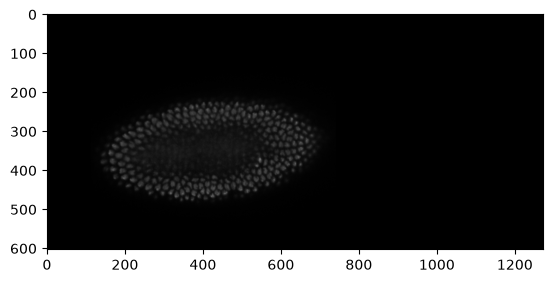

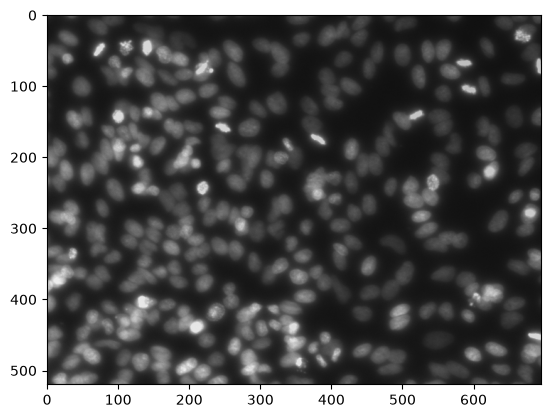

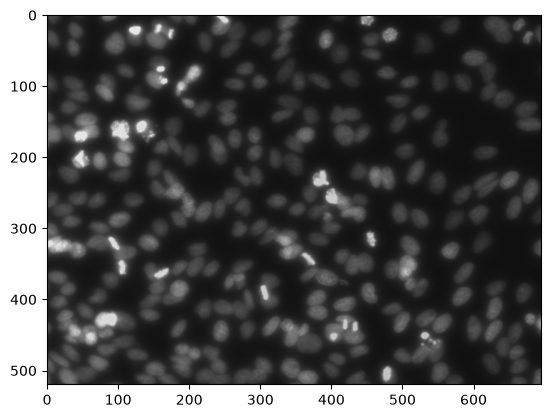

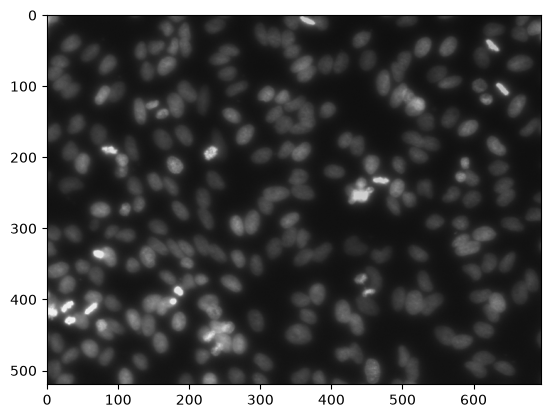

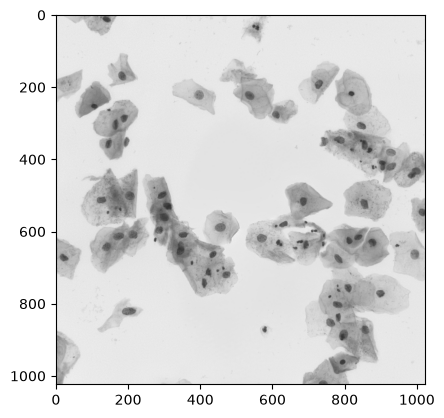

In [21]:
for img_id in top_5_ids:
    img_path = path_train / img_id / 'images' / f'{img_id}.png'
    mask_dir = path_train / img_id / 'masks'

    image = np.array(Image.open(img_path).convert('RGB'))
    plt.imshow(image)
    plt.show()

In [22]:
model_baseline = UNetTernary().to(DEVICE)

rf_baseline, stride_baseline = resnet34_encoder_rf(model_baseline)

model_stride8 = UNetTernary()


for i, block in enumerate(model_stride8.enc4):
    if i == 0:
        block.conv1.stride = (1, 1)

        if block.downsample is not None:
            block.downsample[0].stride = (1, 1)


rf_stride8, stride_stride8 = resnet34_encoder_rf(model_stride8)


In [23]:
model_dilated = UNetTernaryDilated()

rf_dilated, stride_dilated = resnet34_encoder_rf(model_dilated)



In [24]:
print(
    f"Encoder padrão             : "
    f"RF = {rf_baseline} px | "
    f"output stride = {stride_baseline}"
)

print(
    f"Encoder stride 8 sem atrous: "
    f"RF = {rf_stride8} px | "
    f"output stride = {stride_stride8}"
)

print(
    f"Encoder stride 8 com atrous: "
    f"RF = {rf_dilated} px | "
    f"output stride = {stride_dilated}"
)

print(
    f"\nEfeito da dilatação no mesmo output stride: "
    f"+{rf_dilated - rf_stride8} px de RF"
)

Encoder padrão             : RF = 547 px | output stride = 16
Encoder stride 8 sem atrous: RF = 371 px | output stride = 8
Encoder stride 8 com atrous: RF = 563 px | output stride = 8

Efeito da dilatação no mesmo output stride: +192 px de RF


 Distribuição de tamanhos dos objetos do dataset vs. campo receptivo

Percorremos as máscaras individuais (`.../masks/*.png`) de todo o `stage1_train`, medimos o diâmetro equivalente de cada núcleo e comparamos essa distribuição com o RF teórico calculado acima.

29488 instâncias | diâmetro médio = 13.9 px | mediana = 12.0 px | p95 = 32.3 px | máximo = 83.4 px

Objetos com diâmetro <= 8 px: 19.90%
Objetos com diâmetro <= 16 px: 73.01%
Objetos com diâmetro > 16 px: 26.99%


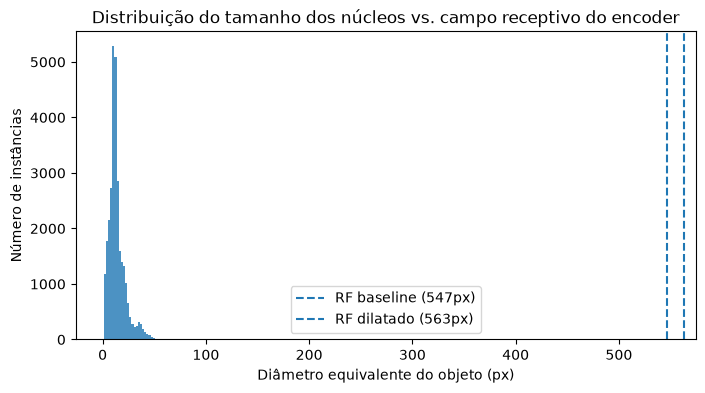

0.00% das instâncias têm diâmetro maior que o RF do encoder padrão.
0.00% das instâncias têm diâmetro maior que o RF do encoder dilatado.


In [25]:
diameters = object_diameters(path_train)

print(
    f"{len(diameters)} instâncias | "
    f"diâmetro médio = {diameters.mean():.1f} px | "
    f"mediana = {np.median(diameters):.1f} px | "
    f"p95 = {np.percentile(diameters, 95):.1f} px | "
    f"máximo = {diameters.max():.1f} px"
)

# Comparação entre o tamanho dos objetos e o output stride
print(
    f"\nObjetos com diâmetro <= {stride_baseline/2:.0f} px: "
    f"{(diameters <= stride_baseline/2).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro <= {stride_baseline:.0f} px: "
    f"{(diameters <= stride_baseline).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro > {stride_baseline:.0f} px: "
    f"{(diameters > stride_baseline).mean()*100:.2f}%"
)

plt.figure(figsize=(8, 4))

plt.hist(
    diameters,
    bins=40,
    alpha=0.8
)

plt.axvline(
    rf_baseline,
    linestyle="--",
    label=f"RF baseline ({rf_baseline}px)"
)

plt.axvline(
    rf_dilated,
    linestyle="--",
    label=f"RF dilatado ({rf_dilated}px)"
)

plt.xlabel("Diâmetro equivalente do objeto (px)")
plt.ylabel("Número de instâncias")

plt.title(
    "Distribuição do tamanho dos núcleos "
    "vs. campo receptivo do encoder"
)

plt.legend()
plt.show()


frac_maior_que_rf = (
    diameters > rf_baseline
).mean() * 100

frac_maior_que_rf_dilated = (
    diameters > rf_dilated
).mean() * 100

print(
    f"{frac_maior_que_rf:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder padrão."
)

print(
    f"{frac_maior_que_rf_dilated:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder dilatado."
)


In [26]:
CHECKPOINT_PATH = "../models/best_model_ternary.pt"


model_final = UNetTernary().to(DEVICE)

model_final.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE,
        weights_only=True
    )
)

model_final.eval()

# Convenção dos canais
BG, INTERIOR, BOUNDARY = 0, 1, 2

In [ ]:
def load_instance_gt(mask_dir):
    """Empilha as máscaras individuais do DSB2018 em um único array rotulado (H, W)."""
    mask_dir = Path(mask_dir)
    gt = None

    for i, p in enumerate(sorted(mask_dir.glob("*.png")), start=1):
        m = np.array(Image.open(p)) > 0

        if gt is None:
            gt = np.zeros(m.shape, dtype=np.int32)

        gt[m] = i

    return gt


IMG_SIZE = 256  # mesmo tamanho usado no treinamento

diagnósticos = []

for img_id in top_5_ids:

    img_path = path_train / img_id / "images" / f"{img_id}.png"
    mask_dir = path_train / img_id / "masks"

    # Imagem original
    image = np.array(
        Image.open(img_path).convert("RGB")
    )
    # Ground truth de instâncias
    gt_instances = load_instance_gt(mask_dir)

    # Preparação da entrada
    inp = (
        TF.to_tensor(
            Image.fromarray(image).resize(
                (IMG_SIZE, IMG_SIZE)
            )
        )
        .unsqueeze(0)
        .to(DEVICE)
    )

    # Predição
    with torch.no_grad():
        logits_cls, dist_pred = model_final(inp)

    # Converte logits em probabilidades
    probs = F.softmax(logits_cls[0], dim=0)

    # Probabilidade de fronteira para visualização
    boundary_prob = probs[BOUNDARY].cpu().numpy()

    # Probabilidades esperadas pelo decode_watershed
    class_probs = [
        probs[BG].cpu().numpy(),
        probs[INTERIOR].cpu().numpy(),
        probs[BOUNDARY].cpu().numpy(),
    ]

    # Mapa de distância previsto
    dist_map = dist_pred[0, 0].cpu().numpy()

    # Watershed
    pred_masks = decode_watershed(
        class_probs,
        dist_map=dist_map
    )

    # Converte as máscaras individuais em um mapa de instâncias
    pred_instances = np.zeros(
        (IMG_SIZE, IMG_SIZE),
        dtype=np.int32
    )

    for instance_id, mask in enumerate(pred_masks, start=1):
        pred_instances[mask > 0] = instance_id

    # Redimensiona GT mantendo IDs das instâncias
    gt_resized = np.array(
        Image.fromarray(
            gt_instances.astype(np.int32)
        ).resize(
            (IMG_SIZE, IMG_SIZE),
            resample=Image.Resampling.NEAREST
        )
    )

    # Diâmetro dos objetos
    diam = [
        r.equivalent_diameter_area
        for r in regionprops(gt_resized)
    ]

    max_diam = max(diam) if diam else 0

    # Métricas da imagem
    linha = df[df["id"] == img_id].iloc[0]

In [ ]:
diagnósticos = []


for img_id in top_5_ids:

    # ============================================================
    # 1. Caminhos
    # ============================================================

    img_path = (
        path_train
        / img_id
        / "images"
        / f"{img_id}.png"
    )

    mask_dir = (
        path_train
        / img_id
        / "masks"
    )


    # ============================================================
    # 2. Imagem original
    # ============================================================

    image = np.array(
        Image.open(img_path).convert("RGB")
    )


    # ============================================================
    # 3. Ground truth de instâncias
    # ============================================================

    gt_instances = load_instance_gt(mask_dir)


    # ============================================================
    # 4. Redimensiona o GT para 256 x 256
    # ============================================================

    gt_resized = np.array(
        Image.fromarray(
            gt_instances.astype(np.int32)
        ).resize(
            (IMG_SIZE, IMG_SIZE),
            resample=Image.Resampling.NEAREST
        )
    )


    # ============================================================
    # 5. Gera o rótulo ternário
    # ============================================================

    ternary_gt = instance_gt_to_ternary(
        gt_resized,
        boundary_width=2
    )


    # ============================================================
    # 6. Prepara a imagem para a rede
    # ============================================================

    inp = (
        TF.to_tensor(
            Image.fromarray(image).resize(
                (IMG_SIZE, IMG_SIZE)
            )
        )
        .unsqueeze(0)
        .to(DEVICE)
    )


    # ============================================================
    # 7. Predição do modelo
    # ============================================================

    model_final.eval()

    with torch.no_grad():
        logits_cls, dist_pred = model_final(inp)


    # ============================================================
    # 8. Probabilidades das três classes
    # ============================================================

    probs = F.softmax(
        logits_cls[0],
        dim=0
    )


    # ============================================================
    # 9. Probabilidade da classe fronteira
    # ============================================================

    boundary_prob = (
        probs[BOUNDARY]
        .cpu()
        .numpy()
    )


    # ============================================================
    # 10. Predição ternária
    # ============================================================

    pred_ternary = torch.argmax(
        logits_cls[0],
        dim=0
    ).cpu().numpy()


    # ============================================================
    # 11. Número de instâncias do ground truth
    # ============================================================

    n_gt = len(
        regionprops(gt_resized)
    )


    # ============================================================
    # 12. Métricas da imagem
    # ============================================================

    linha = df[
        df["id"] == img_id
    ].iloc[0]


    # ============================================================
    # 13. Galeria
    # ============================================================

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )


    # Imagem
    axes[0].imshow(image)
    axes[0].set_title("Imagem")
    axes[0].axis("off")


    # Ground truth de instâncias
    axes[1].imshow(
        gt_instances,
        cmap="nipy_spectral"
    )

    axes[1].set_title(
        f"Ground truth ({n_gt} instâncias)"
    )

    axes[1].axis("off")


    # Ground truth ternário
    axes[2].imshow(
        ternary_gt,
        cmap="viridis",
        vmin=0,
        vmax=2
    )

    axes[2].set_title(
        "Ground truth ternário"
    )

    axes[2].axis("off")


    # Predição ternária
    axes[3].imshow(
        pred_ternary,
        cmap="viridis",
        vmin=0,
        vmax=2
    )

    axes[3].set_title(
        "Predição ternária"
    )

    axes[3].axis("off")


    # Título geral
    fig.suptitle(
        f"{img_id} | "
        f"count_error={linha['count_error']} | "
        f"mAP={linha['mAP_image']:.3f}"
    )


    plt.tight_layout()
    plt.show()


    # ============================================================
    # 14. Diagnóstico
    # ============================================================

    diam = [
        r.equivalent_diameter_area
        for r in regionprops(gt_resized)
    ]

    max_diam = max(diam) if diam else 0


    diagnostico = (
        f"[{img_id}] O maior objeto tem aproximadamente "
        f"{max_diam:.1f} px de diâmetro. "
        f"O rótulo ternário possui {n_gt} instâncias no "
        f"ground truth. A fronteira é definida pela sobreposição "
        f"das dilatações de instâncias vizinhas, evitando que "
        f"objetos isolados recebam uma fronteira artificial "
        f"contra o fundo."
    )


    print(diagnostico)

    diagnósticos.append(
        diagnostico)